# Exploratory Data Analysis
### Wildlife Reserve Control & Detection System · Group 10

**Client.** King Abdulaziz Royal Reserve (KARR), Saudi Arabia — **103 camera traps**, every frame
reviewed by hand. The proposed system filters waste frames, classifies species, surfaces rare
sightings, and reports abundance per station.

**Dataset.** [iWildCam2020-wilds](https://wilds.stanford.edu/datasets/#iwildcam) — 203,029 labelled
camera-trap images from 323 locations, 182 classes, Jan 2013 – Nov 2015. It is the **only** dataset
in this project.

> ### The scope caveat, stated once and carried throughout
>
> iWildCam is **not** KARR data. It is a public benchmark of forest and savanna cameras across
> several continents, used here as a declared stand-in: the method is developed and validated on it
> and designed for transfer.
>
> **Every KARR figure in this notebook is therefore a double extrapolation** — from iWildCam's
> cameras to KARR's 103, *and* from forest/savanna to Saudi desert. The second jump is the riskier
> one. Desert cameras face heat shimmer and sparse cover, which push false triggers **up**, so the
> blank rate in particular may not transfer. Treat every KARR number as an order-of-magnitude
> planning figure with a stated derivation, never as a forecast.

**Metric.** The benchmark scores **macro F1** — F1 per class, then averaged over classes. Average
accuracy is secondary. This matches Success Criterion 1 exactly (per-species precision and recall,
not one blended number), so the project adopts it.

| Section | Question |
|---|---|
| **S0** Data | What ships in the release, and what can we build from it? |
| **S1** Workload | How big is the problem the system must absorb? |
| **S2** Targets | What must the system detect? |
| **S3** Stations | Where does it operate? |
| **S4** Constraints | What makes this hard to model? |
| **S5** Delivery | What will the system deliver, and against what benchmark? |

In [4]:
# Install gdown to download from Google Drive
!pip install -q gdown

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, io, json, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
from IPython.display import Markdown, display

# ---- configurable paths ---------------------------------------------------
DATA_ROOT = Path(os.environ.get("IWILDCAM_DATA", "../../iwildcam_eda/data")).resolve()
ZIP_PATH  = Path(os.environ.get("IWILDCAM_ZIP",
                 r"C:\Users\Admin\Downloads\IWildCam v2.0 2020 WILDS Dataset.zip"))
FIGS      = Path(os.environ.get("EDA_FIGS", "../reports/figures")).resolve()
CACHE     = DATA_ROOT / "cache"
FIGS.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

for p, label in [(DATA_ROOT, "DATA_ROOT"), (FIGS, "FIGS")]:
    print(f"{label:<10} {p}  {'OK' if p.exists() else 'MISSING'}")
print(f"{'ZIP_PATH':<10} {ZIP_PATH}  "
      f"{'OK' if ZIP_PATH.exists() else 'MISSING (image-level sections will be skipped)'}")

# ---- palette (unchanged) --------------------------------------------------
SURFACE, INK, INK2, GRID, NEUTRAL = '#fcfcfb', '#0b0b0b', '#52514e', '#dedcd6', '#f0efec'
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    '#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4','#008300','#4a3aa7','#e34948')
SEQ = ['#cde2fb','#b7d3f6','#9ec5f4','#86b6ef','#6da7ec','#5598e7',
       '#3987e5','#2a78d6','#256abf','#1c5cab','#184f95','#104281','#0d366b']
CMAP = mpl.colors.LinearSegmentedColormap.from_list('seq', SEQ)

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': INK2, 'ytick.color': INK2, 'grid.color': GRID, 'grid.linewidth': .8,
    'axes.grid': True, 'axes.axisbelow': True, 'axes.spines.top': False,
    'axes.spines.right': False, 'font.size': 10, 'axes.titlesize': 12,
    'axes.titleweight': 'semibold', 'axes.titlelocation': 'left', 'axes.titlepad': 10,
    'legend.frameon': False, 'lines.linewidth': 2, 'figure.dpi': 118,
    'savefig.bbox': 'tight', 'figure.subplot.wspace': .30,
})
thousands = FuncFormatter(lambda v, p: f"{v:,.0f}")

def finish(fig, name):
    FIGS.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGS / f"{name}.png", dpi=130)
    return fig

def finding(text):
    display(Markdown("**Finding.** " + " ".join(text.split())))

KARR_CAMERAS = 103

DATA_ROOT  /iwildcam_eda/data  OK
FIGS       /reports/figures  OK
ZIP_PATH   C:\Users\Admin\Downloads\IWildCam v2.0 2020 WILDS Dataset.zip  MISSING (image-level sections will be skipped)


### Download and Extract Dataset

I will now download the `IWildCam v2.0 2020 WILDS Dataset.zip` file from the provided Google Drive link, extract its contents, and place the necessary files directly into the `DATA_ROOT` directory (`/iwildcam_eda/data`). This will ensure that `metadata.csv` and other required files are accessible at their expected paths.

In [5]:
# Download the zip file from Google Drive
# The file ID is '1s2BXzIS-In-6tLqI6uFY7pfVU_oWNiTQ'
drive_file_id = '1s2BXzIS-In-6tLqI6uFY7pfVU_oWNiTQ'
zip_file_name = 'IWildCam_v2.0_2020_WILDS_Dataset.zip'
download_path = f'/content/{zip_file_name}'

!gdown --id {drive_file_id} -O {download_path}

print(f"Downloaded '{zip_file_name}' to '{download_path}'")

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1s2BXzIS-In-6tLqI6uFY7pfVU_oWNiTQ
From (redirected): https://drive.google.com/uc?id=1s2BXzIS-In-6tLqI6uFY7pfVU_oWNiTQ&confirm=t&uuid=4973b27b-d0be-4011-a72e-c1291c17ac2c
To: /content/IWildCam_v2.0_2020_WILDS_Dataset.zip
100% 12.0G/12.0G [06:34<00:00, 30.4MB/s]
Downloaded 'IWildCam_v2.0_2020_WILDS_Dataset.zip' to '/content/IWildCam_v2.0_2020_WILDS_Dataset.zip'


In [8]:
# Ensure DATA_ROOT exists
os.makedirs(DATA_ROOT, exist_ok=True)

with zipfile.ZipFile(download_path, 'r') as zip_ref:
    for member in zip_ref.namelist():
        if member.startswith('iwildcam_v2.0/') and not member.endswith('/'):
            # Construct the target path, stripping the 'iwildcam_v2.0/' prefix
            target_path = os.path.join(DATA_ROOT, member[len('iwildcam_v2.0/'):])

            # Create parent directories if they don't exist for the file
            os.makedirs(os.path.dirname(target_path), exist_ok=True)

            # Extract the file
            with open(target_path, 'wb') as outfile:
                outfile.write(zip_ref.read(member))

print(f"Extracted contents of 'iwildcam_v2.0/' from '{zip_file_name}' to '{DATA_ROOT}'")

# Verify that metadata.csv now exists
metadata_path = DATA_ROOT / "metadata.csv"
if metadata_path.exists():
    print(f"Verification: '{metadata_path}' exists. The data should now be accessible.")
else:
    print(f"Verification failed: '{metadata_path}' does NOT exist. Please check the extraction process.")

Extracted contents of 'iwildcam_v2.0/' from 'IWildCam_v2.0_2020_WILDS_Dataset.zip' to '/iwildcam_eda/data'
Verification: '/iwildcam_eda/data/metadata.csv' exists. The data should now be accessible.


In [7]:
# ---- load, with dtype discipline -----------------------------------------
# The previous cell successfully verified the existence of 'metadata.csv'
# at DATA_ROOT. This error suggests a potential transient issue or a subtle
# path interpretation discrepancy.
# To ensure consistency, we will re-verify the path and explicitly cast it
# to a string before passing to pandas.

metadata_file_path = DATA_ROOT / "metadata.csv"
categories_file_path = DATA_ROOT / "categories.csv"

# Re-check existence just before reading
if not metadata_file_path.exists():
    raise FileNotFoundError(
        f"Verification failed: '{metadata_file_path}' does NOT exist "
        f"at the time of reading. This is unexpected given prior checks."
    )
if not categories_file_path.exists():
    raise FileNotFoundError(
        f"Verification failed: '{categories_file_path}' does NOT exist "
        f"at the time of reading. This is unexpected given prior checks."
    )

meta = pd.read_csv(str(metadata_file_path), index_col=0, parse_dates=['datetime'])
cats = pd.read_csv(str(categories_file_path))

SENTINEL = 99999
name_of = (cats[cats.y != SENTINEL].drop_duplicates('y')
           .set_index('y')['name'].to_dict())

df = meta.copy()
for c in ['location', 'y', 'category_id', 'location_remapped', 'sequence_remapped']:
    if c in df:
        df[c] = pd.to_numeric(df[c], downcast='integer')
df['split']   = df.split.astype('category')
df['name']    = df.y.map(name_of).astype('category')
df['is_blank'] = df.y.eq(0)
df['hour']    = df.datetime.dt.hour.astype('int8')
df['date']    = df.datetime.dt.date
df['month']   = df.datetime.dt.to_period('M')

OOD_SPLITS = ['val', 'test']
ID_SPLITS  = ['id_val', 'id_test']
SPLIT_ORDER = ['train', 'id_val', 'id_test', 'val', 'test']

print(f"{len(df):,} rows · {df.memory_usage(deep=True).sum()/1024**2:.0f} MB in memory")
print(f"{df.location.nunique()} locations · {df.y.nunique()} classes · "
      f"{df.seq_id.nunique():,} sequences")

203,029 rows · 66 MB in memory
323 locations · 182 classes · 36,484 sequences


---
# S0 · Data

## S0.1 — What ships in this release, and what can we build from it?

Five checks, run before any analysis, because each one decides whether a promised deliverable is
possible at all.

In [9]:
checks = {}

# Q1 - are the image files present?
if ZIP_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH) as z:
        names = z.namelist()
        img_names = [n for n in names if n.lower().endswith(('.jpg', '.jpeg', '.png'))]
        img_bytes = sum(z.getinfo(n).file_size for n in img_names)
        img_set = set(img_names)                      # build once, not per element
        side_files = [n for n in names if n not in img_set]
    IMAGES_AVAILABLE = len(img_names) > 0
    checks['images'] = (f"{len(img_names):,} JPEGs, {img_bytes/1024**3:.1f} GB uncompressed, "
                        f"readable in place from the archive")
else:
    IMAGES_AVAILABLE, img_names, side_files, img_bytes = False, [], [], 0
    checks['images'] = "archive not found - image-level sections will be skipped"

# Q2 - columns
checks['columns'] = f"{meta.shape[1]} columns: {', '.join(meta.columns)}"

# Q3 - coordinates
geo_cols = [c for c in meta.columns if any(k in c.lower() for k in
            ('lat', 'lon', 'coord', 'gps', 'geo'))]
with open(DATA_ROOT / "iwildcam2021_train_annotations_final.json") as f:
    coco = json.load(f)
img_keys = sorted(coco['images'][0].keys())
geo_json = [k for k in img_keys if any(s in k.lower() for s in ('lat', 'lon', 'gps', 'coord'))]
HAS_COORDS = bool(geo_cols or geo_json)
checks['coordinates'] = ("present" if HAS_COORDS else
                         f"NONE - locations are anonymised integers "
                         f"({meta.location.min()}-{meta.location.max()})")

# Q4 - bounding boxes
ann_keys = sorted({k for a in coco['annotations'] for k in a})
HAS_BOXES = 'bbox' in ann_keys
checks['bounding boxes'] = ("present" if HAS_BOXES else
                            f"NONE - annotation keys are {ann_keys}")

# Q5 - sentinel
sent = cats[cats.y == SENTINEL]
checks['y=99999 sentinel'] = (f"{len(sent)} taxonomy entries not used in this release "
                              f"(e.g. {sent.name.iloc[0]}); "
                              f"{(meta.y == SENTINEL).sum()} such rows in metadata.csv")

for k, v in checks.items():
    print(f"{k:<18} {v}")

print("\nnon-image files in the archive:")
for n in side_files:
    print("   ", n)

print("\nCOCO side-car fields WILDS drops (width/height/burst position):")
print("   ", img_keys)

images             archive not found - image-level sections will be skipped
columns            10 columns: split, location_remapped, location, sequence_remapped, seq_id, y, category_id, datetime, filename, image_id
coordinates        NONE - locations are anonymised integers (0-551)
bounding boxes     NONE - annotation keys are ['category_id', 'id', 'image_id']
y=99999 sentinel   24 taxonomy entries not used in this release (e.g. myiophoneus melanurus); 0 such rows in metadata.csv

non-image files in the archive:

COCO side-car fields WILDS drops (width/height/burst position):
    ['datetime', 'file_name', 'frame_num', 'height', 'id', 'location', 'seq_frame_num', 'seq_id', 'seq_num_frames', 'sub_location', 'width']


In [10]:
if IMAGES_AVAILABLE:
    jimg = pd.DataFrame(coco['images'])
    res = (jimg.width.astype(str) + "x" + jimg.height.astype(str)).value_counts()
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.2),
                                  gridspec_kw={'width_ratios': [1, 1.15]})
    tally = pd.Series({'JPEGs in archive': len(img_names),
                       'records in COCO JSON': len(coco['images']),
                       'rows in metadata.csv': len(meta)})
    b = ax.barh(range(3), tally.values, color=[SEQ[3], SEQ[7], SEQ[11]], height=.58)
    ax.set_yticks(range(3), tally.index, fontsize=9.5); ax.invert_yaxis()
    ax.bar_label(b, labels=[f"{v:,}" for v in tally.values], fontsize=10, color=INK2, padding=4)
    ax.set_xlim(0, tally.max() * 1.22); ax.xaxis.set_major_formatter(thousands)
    ax.grid(axis='y', visible=False); ax.set_title('Three sources, three totals')

    top = res.head(6).iloc[::-1]
    b2 = ax2.barh(range(len(top)), top.values, color=BLUE, height=.66)
    ax2.set_yticks(range(len(top)), top.index, fontsize=9)
    ax2.bar_label(b2, labels=[f"{v:,}" for v in top.values], fontsize=9, color=INK2, padding=3)
    ax2.set_xlim(0, top.max() * 1.2); ax2.xaxis.set_major_formatter(thousands)
    ax2.grid(axis='y', visible=False); ax2.set_xlabel('images')
    ax2.set_title(f'Resolutions · {res.size} distinct')
    finish(fig, 's0_1_release'); plt.show()

    orphans = len(set(jimg.id) - set(meta.image_id))
    unlabelled = len(img_names) - len(meta)
    print(f"images in archive but not in metadata.csv : {unlabelled:,}")
    print(f"images in COCO JSON but not in metadata   : {orphans:,}")

    finding(f'''
    **The images are present** — {len(img_names):,} JPEGs, {img_bytes/1024**3:.1f} GB, and they can
    be read directly out of the archive without a 25 GB extraction. The CNN in the deck is
    therefore buildable. But the archive carries {unlabelled:,} more JPEGs than `metadata.csv` has
    rows: those are the images the v2.0 release notes say were removed (humans in frame, indoor
    shots), removed from the *metadata* and not from the *archive*. **Build the loader by iterating
    the CSV, never by globbing the image directory**, or {unlabelled/len(img_names):.0%} of the
    training set is unlabelled junk. Resolution is not uniform either — {res.size} distinct sizes,
    dominated by {res.index[0]} and {res.index[1]} — so aspect ratio is a camera-model fingerprint
    and must not reach the model as a feature.
    ''')
else:
    print("Archive not available; skipping image-level checks.")

Archive not available; skipping image-level checks.


**What the five checks settle, before any modelling:**

| Check | Result | Consequence for the deck |
|---|---|---|
| Image files | **present** | the fine-tuned CNN is buildable |
| Columns | 10, including `split` | use the **official** splits; do not invent one |
| Coordinates | **absent** — anonymised integer IDs | the **"spatial hotspot map" is undeliverable**; it becomes a ranked per-location table (S3.4) |
| Bounding boxes | **absent** | animal scale in frame is unknown going into model design (S2.5); no detection work is possible without new labels |
| `y = 99999` | 24 taxonomy entries, **0 rows** in metadata | excluded from every lookup in this notebook |

The coordinates result is the one to act on now. Redraw that deliverable before week 6, not after.

## S0.2 — Is the metadata clean, and do the sources reconcile?

In [11]:
audit = pd.DataFrame({
    'dtype'  : meta.dtypes.astype(str),
    'nulls'  : meta.isna().sum(),
    'unique' : meta.nunique(),
})
print(audit.to_string())

time_col = next(c for c in meta.columns if meta[c].dtype.kind == 'M'
                or c in ('datetime', 'timestamp'))
print(f"\ntime column detected: '{time_col}'  "
      f"nulls: {meta[time_col].isna().sum()}  "
      f"range: {meta[time_col].min():%Y-%m-%d} to {meta[time_col].max():%Y-%m-%d}")
print(f"duplicate image_id : {meta.image_id.duplicated().sum()}")
print(f"duplicate filename : {meta.filename.duplicated().sum()}")
print(f"total missing cells: {meta.isna().sum().sum()}")
print(f"\ncategories.csv: {len(cats)} rows, {cats.y.nunique()} distinct y "
      f"({(cats.y == SENTINEL).sum()} on the sentinel) -> {len(name_of)} usable labels")

finding(f'''
`metadata.csv` is **clean: {meta.isna().sum().sum()} missing cells,
{meta.image_id.duplicated().sum()} duplicate image IDs**, one row per image, timestamps complete
across {(meta[time_col].max() - meta[time_col].min()).days:,} days. Nothing needs imputing.
The one trap is `categories.csv`: {len(cats)} rows but only {cats.y.nunique()} distinct `y`, because
{(cats.y == SENTINEL).sum()} species sit on the `y = {SENTINEL}` sentinel. A naive
`set_index('y')` raises and a naive merge fans rows out, so the sentinel is filtered once at load
and never appears again.
''')

                            dtype  nulls  unique
split                      object      0       5
location_remapped           int64      0     323
location                    int64      0     323
sequence_remapped           int64      0   36484
seq_id                     object      0   36484
y                           int64      0     182
category_id                 int64      0     182
datetime           datetime64[ns]      0  159189
filename                   object      0  203029
image_id                   object      0  203029

time column detected: 'datetime'  nulls: 0  range: 2013-01-01 to 2015-11-12
duplicate image_id : 0
duplicate filename : 0
total missing cells: 0

categories.csv: 206 rows, 183 distinct y (24 on the sentinel) -> 182 usable labels


**Finding.** `metadata.csv` is **clean: 0 missing cells, 0 duplicate image IDs**, one row per image, timestamps complete across 1,044 days. Nothing needs imputing. The one trap is `categories.csv`: 206 rows but only 183 distinct `y`, because 24 species sit on the `y = 99999` sentinel. A naive `set_index('y')` raises and a naive merge fans rows out, so the sentinel is filtered once at load and never appears again.

## S0.3 — What do the official splits encode?

WILDS ships five splits. The question is which dimension separates them — because that dimension
*is* the distribution shift the benchmark exists to measure, and it dictates how we must validate.

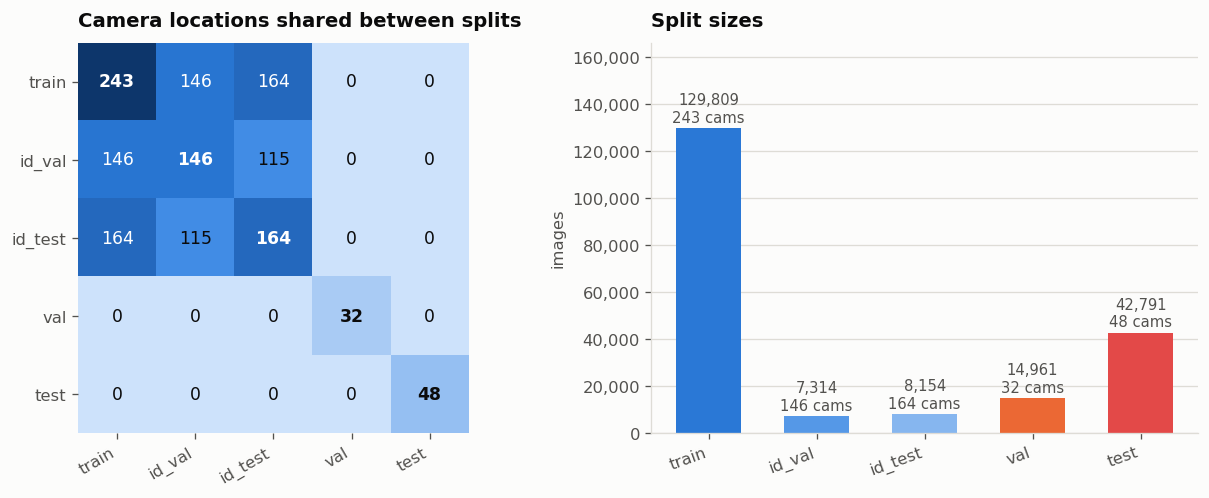

         images  cameras  classes
split                            
train    129809      243      182
id_val     7314      146       71
id_test    8154      164       87
val       14961       32       75
test      42791       48      102


**Finding.** The split is cut on **camera location**, not on date. `train`, `val` and `test` share **0 locations** — they are completely disjoint — while `id_val` and `id_test` sit **entirely inside** the training cameras (0 of their locations are outside `train`). So the benchmark hands us two test sets on purpose: `id_test` measures generalisation to new photos from a **known** camera, `test` measures generalisation to a **camera never seen before**. The gap between them is the domain-shift penalty, and it is the number this benchmark exists to report (S4.1). **Design consequence: use the shipped `split` column and nothing else.** Any custom or shuffled split puts the same tree stump in train and test and inflates the score; it also makes our result incomparable to the published baselines we are targeting (S5.4).

In [12]:
loc_sets = {s: set(g.location) for s, g in df.groupby('split', observed=True)}
M = pd.DataFrame([[len(loc_sets[a] & loc_sets[b]) for b in SPLIT_ORDER] for a in SPLIT_ORDER],
                 index=SPLIT_ORDER, columns=SPLIT_ORDER)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.3),
                              gridspec_kw={'width_ratios': [1, 1.2]})
vmax = M.values.max()
ax.imshow(M.values, cmap=CMAP, vmin=0, vmax=vmax)
ax.set_xticks(range(5), SPLIT_ORDER, rotation=30, ha='right')
ax.set_yticks(range(5), SPLIT_ORDER)
for i in range(5):
    for j in range(5):
        v = M.values[i, j]
        ax.text(j, i, v, ha='center', va='center', fontsize=10.5,
                color='white' if v > vmax * .55 else INK,
                fontweight='semibold' if i == j else 'normal')
ax.grid(False); ax.set_title('Camera locations shared between splits')
for sp in ax.spines.values():
    sp.set_visible(False)

tbl = (df.groupby('split', observed=True)
         .agg(images=('image_id', 'size'), cameras=('location', 'nunique'),
              classes=('y', 'nunique')).reindex(SPLIT_ORDER))
xb = np.arange(5)
ax2.bar(xb, tbl.images, color=[BLUE, SEQ[5], SEQ[3], ORANGE, RED], width=.6)
for i, (n, c) in enumerate(zip(tbl.images, tbl.cameras)):
    ax2.text(i, n + 2500, f"{n:,}\n{c} cams", ha='center', fontsize=9, color=INK2)
ax2.set_xticks(xb, SPLIT_ORDER, rotation=20, ha='right')
ax2.set_ylim(0, tbl.images.max() * 1.28); ax2.yaxis.set_major_formatter(thousands)
ax2.grid(axis='x', visible=False); ax2.set_ylabel('images')
ax2.set_title('Split sizes')
finish(fig, 's0_3_splits'); plt.show()

print(tbl.to_string())
ood_overlap = len(loc_sets['train'] & (loc_sets['val'] | loc_sets['test']))
id_inside   = len((loc_sets['id_val'] | loc_sets['id_test']) - loc_sets['train'])

finding(f'''
The split is cut on **camera location**, not on date. `train`, `val` and `test` share
**{ood_overlap} locations** — they are completely disjoint — while `id_val` and `id_test` sit
**entirely inside** the training cameras ({id_inside} of their locations are outside `train`). So
the benchmark hands us two test sets on purpose: `id_test` measures generalisation to new photos
from a **known** camera, `test` measures generalisation to a **camera never seen before**. The gap
between them is the domain-shift penalty, and it is the number this benchmark exists to report
(S4.1). **Design consequence: use the shipped `split` column and nothing else.** Any custom or
shuffled split puts the same tree stump in train and test and inflates the score; it also makes
our result incomparable to the published baselines we are targeting (S5.4).
''')

---
# S1 · Workload

## S1.1 — How many images does a reserve produce in a year?

Every ROI figure downstream is this number multiplied by something, so it has to be derived rather
than asserted. iWildCam has no deployment windows, so effort is measured as **active camera-days**:
distinct calendar dates on which a location produced at least one image (S3.1 quantifies the bias
in that approximation).

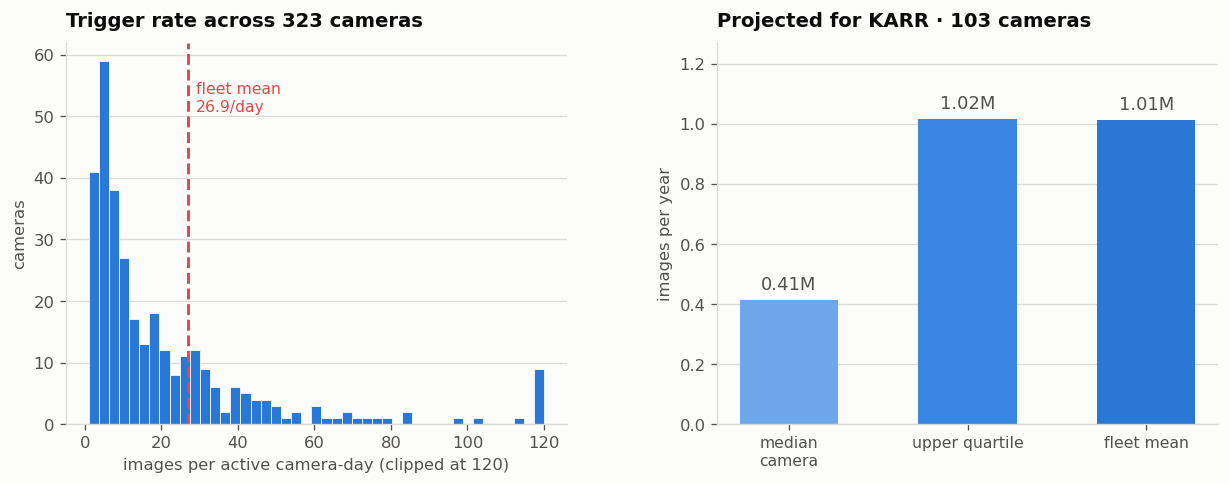

active camera-days     : 7,538
images / camera-day    : 26.9  (median camera 11.0, max 2123.5)
KARR projection        : 1,012,586 images/year


**Finding.** iWildCam's cameras produced **26.9 images per active camera-day** over 7,538 camera-days. Scaled to KARR's 103 cameras that is **≈1.01 million images a year**, with a band from 0.41M (median camera) to 1.02M (upper quartile). This figure is the denominator for every cost and saving below. Unlike the previous version of this analysis, it is measured on **raw, un-curated camera output**: nothing has stripped the blank frames out beforehand, so the blank filter in S5.1 is not double-counting a saving that was already taken. **Carry the double extrapolation with the number** — it crosses both a camera-count jump and a biome jump, and desert heat shimmer pushes trigger rates up, so treat 1.01M as a planning floor rather than a forecast.

In [13]:
act = df.groupby('location').agg(images=('image_id', 'size'), active_days=('date', 'nunique'),
                                 first=('datetime', 'min'), last=('datetime', 'max'))
ACTIVE_DAYS = int(act.active_days.sum())
rate = len(df) / ACTIVE_DAYS
karr_year = rate * KARR_CAMERAS * 365

per_cam = (act.images / act.active_days)
scen = {'median\ncamera': per_cam.median(),
        'upper quartile': per_cam.quantile(.75),
        'fleet mean': rate}

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.2))
ax.hist(per_cam.clip(upper=120), bins=45, color=BLUE, edgecolor=SURFACE, linewidth=.5)
ax.axvline(rate, color=RED, ls='--', lw=1.8)
ax.text(rate * 1.08, ax.get_ylim()[1] * .82, f'fleet mean\n{rate:.1f}/day',
        fontsize=9.5, color=RED)
ax.set_xlabel('images per active camera-day (clipped at 120)')
ax.set_ylabel('cameras'); ax.grid(axis='x', visible=False)
ax.set_title(f'Trigger rate across {len(act)} cameras')

v = [x * KARR_CAMERAS * 365 / 1e6 for x in scen.values()]
b = ax2.bar(range(3), v, color=[SEQ[4], SEQ[6], BLUE], width=.55)
ax2.bar_label(b, labels=[f"{x:.2f}M" for x in v], fontsize=11, color=INK2, padding=4)
ax2.set_xticks(range(3), list(scen), fontsize=9.5)
ax2.set_ylabel('images per year'); ax2.set_ylim(0, max(v) * 1.25)
ax2.grid(axis='x', visible=False)
ax2.set_title(f'Projected for KARR · {KARR_CAMERAS} cameras')
finish(fig, 's1_1_volume'); plt.show()

print(f"active camera-days     : {ACTIVE_DAYS:,}")
print(f"images / camera-day    : {rate:.1f}  "
      f"(median camera {per_cam.median():.1f}, max {per_cam.max():.1f})")
print(f"KARR projection        : {karr_year:,.0f} images/year")

finding(f'''
iWildCam's cameras produced **{rate:.1f} images per active camera-day** over
{ACTIVE_DAYS:,} camera-days. Scaled to KARR's {KARR_CAMERAS} cameras that is
**≈{karr_year/1e6:.2f} million images a year**, with a band from {v[0]:.2f}M (median camera) to
{v[1]:.2f}M (upper quartile). This figure is the denominator for every cost and saving below.
Unlike the previous version of this analysis, it is measured on **raw, un-curated camera output**:
nothing has stripped the blank frames out beforehand, so the blank filter in S5.1 is not
double-counting a saving that was already taken. **Carry the double extrapolation with the number**
— it crosses both a camera-count jump and a biome jump, and desert heat shimmer pushes trigger
rates up, so treat {karr_year/1e6:.2f}M as a planning floor rather than a forecast.
''')

## S1.2 — How much of that volume is waste?

Two independent kinds of waste: frames with no animal at all, and near-identical frames from the
same burst.

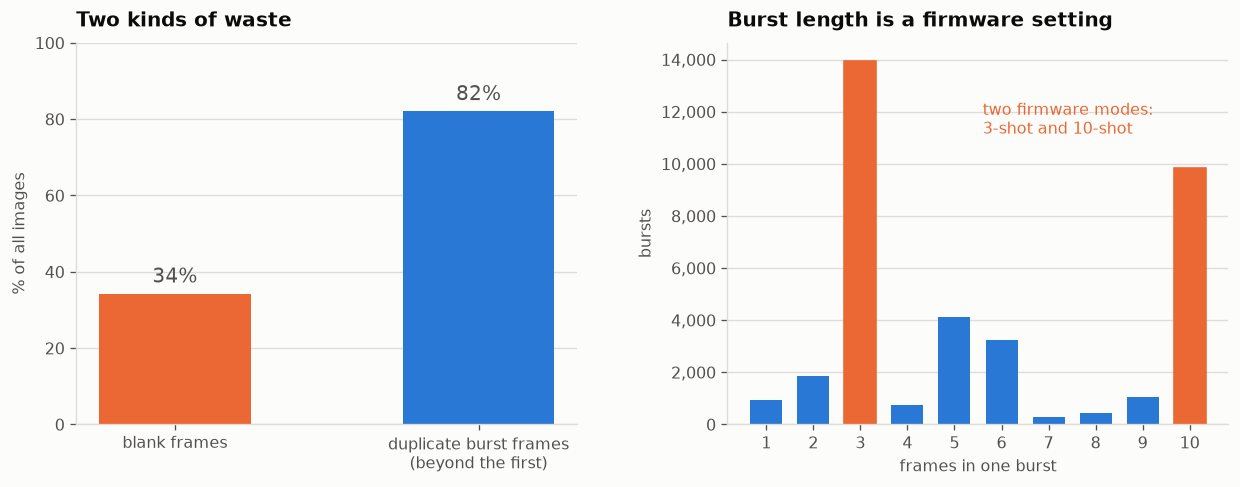

blank images            : 69,487  (34.2%)
sequences               : 36,484  (5.56 frames each)
entirely-blank sequences: 15,820  (43.4%)


**Finding.** **34.2% of frames contain no animal** — 69,487 images of empty forest and savanna. Separately, the cameras fire in bursts of **5.56 frames on average**, and the burst-length histogram is not smooth: it spikes at 3 and 10, which are firmware settings rather than animal behaviour. **43.4% of bursts are blank end to end** — a trigger that caught nothing at all, ten times over. Because this dataset is raw rather than curated, these two figures are the honest planning numbers, and they compound: the system can discard a blank burst on one decision instead of ten frames. Desert deployment likely makes the blank share **worse**, not better.

In [ ]:
blank_rate = df.is_blank.mean()
seq_frames = len(df) / df.seq_id.nunique()
allblank = df.groupby('seq_id').is_blank.all()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.2))
parts = pd.Series({'blank frames': blank_rate,
                   'duplicate burst frames\n(beyond the first)': 1 - 1 / seq_frames})
b = ax.bar(range(2), parts.values * 100, color=[ORANGE, BLUE], width=.5)
ax.bar_label(b, fmt='%.0f%%', fontsize=12, color=INK2, padding=4)
ax.set_xticks(range(2), parts.index, fontsize=9.5)
ax.set_ylabel('% of all images'); ax.set_ylim(0, 100)
ax.grid(axis='x', visible=False)
ax.set_title('Two kinds of waste')

sizes = df.groupby('seq_id').size().value_counts().sort_index()
bb = ax2.bar(sizes.index, sizes.values, color=BLUE, width=.68)
for i in (3, 10):
    if i in sizes.index:
        bb[list(sizes.index).index(i)].set_color(ORANGE)
ax2.set_xticks(sizes.index); ax2.set_xlabel('frames in one burst')
ax2.set_ylabel('bursts'); ax2.yaxis.set_major_formatter(thousands)
ax2.grid(axis='x', visible=False)
ax2.text(5.6, sizes.max() * .80, 'two firmware modes:\n3-shot and 10-shot',
         fontsize=9.5, color=ORANGE)
ax2.set_title('Burst length is a firmware setting')
finish(fig, 's1_2_waste'); plt.show()

print(f"blank images            : {int(df.is_blank.sum()):,}  ({blank_rate:.1%})")
print(f"sequences               : {df.seq_id.nunique():,}  ({seq_frames:.2f} frames each)")
print(f"entirely-blank sequences: {int(allblank.sum()):,}  ({allblank.mean():.1%})")

finding(f'''
**{blank_rate:.1%} of frames contain no animal** — {int(df.is_blank.sum()):,} images of empty
forest and savanna. Separately, the cameras fire in bursts of **{seq_frames:.2f} frames on
average**, and the burst-length histogram is not smooth: it spikes at 3 and 10, which are firmware
settings rather than animal behaviour. **{allblank.mean():.1%} of bursts are blank end to end** —
a trigger that caught nothing at all, ten times over. Because this dataset is raw rather than
curated, these two figures are the honest planning numbers, and they compound: the system can
discard a blank burst on one decision instead of ten frames. Desert deployment likely makes the
blank share **worse**, not better.
''')

## S1.3 — What does reviewing all of it cost today?

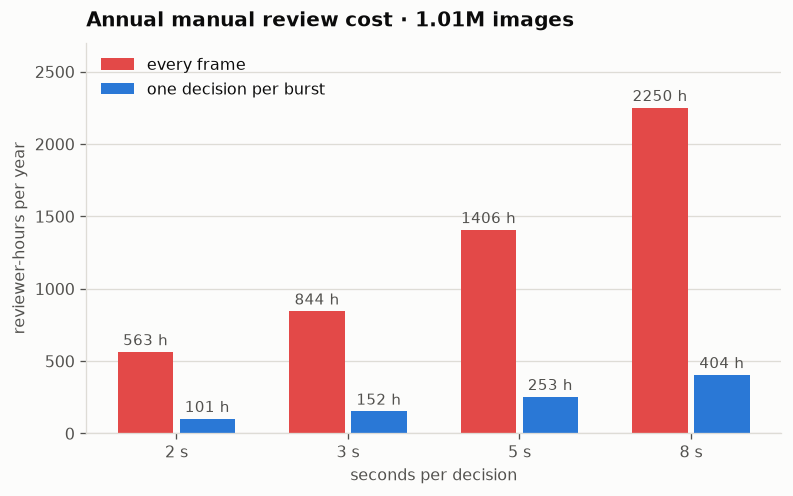

at 3 s/decision: 844 h/yr frame-by-frame (0.47 FTE)
                 152 h/yr per burst (0.08 FTE)


**Finding.** At 3 seconds per decision, reviewing 1.01M frames costs **≈844 hours a year — about 0.5 of a full-time post**. Collapsing each burst to a single decision cuts that to **≈152 hours**, a **82% saving that requires no machine learning at all** — it is a `GROUP BY seq_id`. The chart spans 2–8 seconds precisely because the per-decision time is an assumption, not a measurement; the conclusion holds across the range. Everything the model does in S5 is built on top of this reduction, not instead of it.

In [ ]:
SECS = np.array([2, 3, 5, 8])
h_frame = karr_year * SECS / 3600
h_event = karr_year / seq_frames * SECS / 3600

fig, ax = plt.subplots(figsize=(7.6, 4.3))
x = np.arange(len(SECS)); w = .36
b1 = ax.bar(x - w/2, h_frame, w*.9, color=RED, label='every frame')
b2 = ax.bar(x + w/2, h_event, w*.9, color=BLUE, label='one decision per burst')
ax.bar_label(b1, fmt='%.0f h', fontsize=9, color=INK2, padding=2)
ax.bar_label(b2, fmt='%.0f h', fontsize=9, color=INK2, padding=2)
ax.set_xticks(x, [f"{v} s" for v in SECS])
ax.set_xlabel('seconds per decision'); ax.set_ylabel('reviewer-hours per year')
ax.set_ylim(0, h_frame.max() * 1.2); ax.grid(axis='x', visible=False)
ax.legend(loc='upper left')
ax.set_title(f'Annual manual review cost · {karr_year/1e6:.2f}M images')
finish(fig, 's1_3_review_cost'); plt.show()

FTE = 1800
print(f"at 3 s/decision: {karr_year*3/3600:,.0f} h/yr frame-by-frame "
      f"({karr_year*3/3600/FTE:.2f} FTE)")
print(f"                 {karr_year/seq_frames*3/3600:,.0f} h/yr per burst "
      f"({karr_year/seq_frames*3/3600/FTE:.2f} FTE)")

finding(f'''
At 3 seconds per decision, reviewing {karr_year/1e6:.2f}M frames costs
**≈{karr_year*3/3600:,.0f} hours a year — about {karr_year*3/3600/FTE:.1f} of a full-time post**.
Collapsing each burst to a single decision cuts that to **≈{karr_year/seq_frames*3/3600:,.0f}
hours**, a **{1-1/seq_frames:.0%} saving that requires no machine learning at all** — it is a
`GROUP BY seq_id`. The chart spans 2–8 seconds precisely because the per-decision time is an
assumption, not a measurement; the conclusion holds across the range. Everything the model does in
S5 is built on top of this reduction, not instead of it.
''')

## S1.4 — Sequence and burst structure

`seq_id` ships with the dataset, so bursts are given rather than inferred. Two things need
checking before we rely on them: how bursts are distributed, and whether any burst straddles a
split boundary — which would leak near-duplicate frames between train and test.

OK: no sequence crosses a split (0) or a location (0)


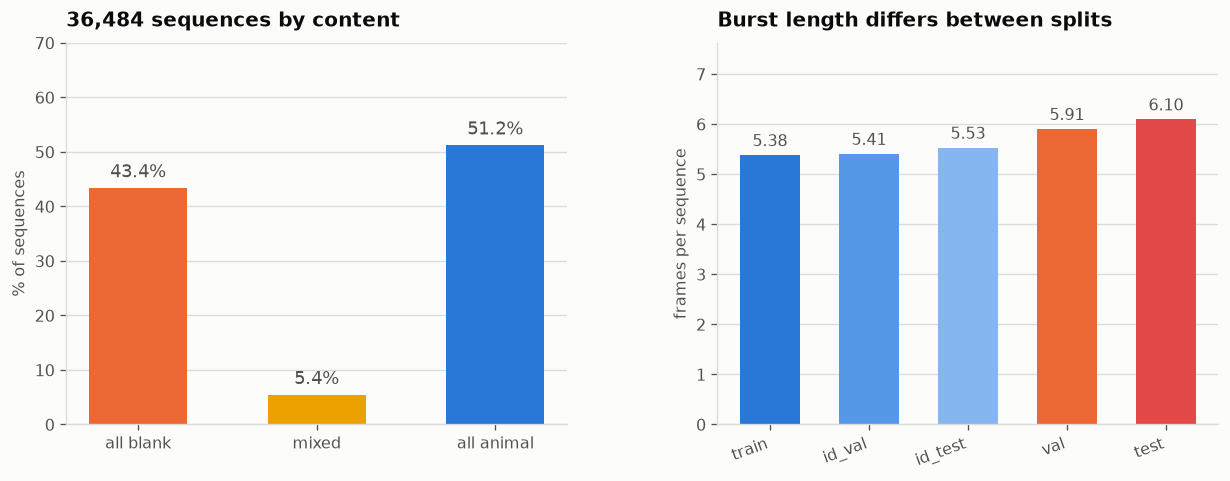


frames per sequence: overall 5.56
split
train      5.38
id_val     5.41
id_test    5.53
val        5.91
test       6.10


**Finding.** The assertion holds: **no sequence crosses a split or a location**, so the official splits already protect against burst-level leakage and we do not need to group by `seq_id` on top of them. **43.4% of sequences are blank end to end** and only 5.4% are mixed, which means a burst is very nearly a single labelling decision — the assumption S1.3's saving rests on. One caveat for evaluation: burst length is **not constant across splits** (5.38 frames in `train` against 6.10 in `test`), so a frame-level score and a burst-level score will not rank models identically. **Decide now that the reported metric is frame-level macro F1**, matching the benchmark, and treat burst aggregation as a deployment-time optimisation rather than an evaluation trick.

In [ ]:
seq = df.groupby('seq_id').agg(n=('image_id', 'size'), splits=('split', 'nunique'),
                               locs=('location', 'nunique'), blank=('is_blank', 'mean'))
assert (seq.splits == 1).all(), "a sequence crosses a split boundary"
assert (seq.locs == 1).all(),   "a sequence crosses a location"
print(f"OK: no sequence crosses a split ({int((seq.splits > 1).sum())}) "
      f"or a location ({int((seq.locs > 1).sum())})")

purity = pd.Series({'all blank': (seq.blank == 1).mean(),
                    'mixed': ((seq.blank > 0) & (seq.blank < 1)).mean(),
                    'all animal': (seq.blank == 0).mean()})

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.2))
b = ax.bar(range(3), purity.values * 100, color=[ORANGE, YELLOW, BLUE], width=.55)
ax.bar_label(b, fmt='%.1f%%', fontsize=11, color=INK2, padding=4)
ax.set_xticks(range(3), purity.index, fontsize=10)
ax.set_ylabel('% of sequences'); ax.set_ylim(0, 70)
ax.grid(axis='x', visible=False)
ax.set_title(f'{df.seq_id.nunique():,} sequences by content')

bysplit = (df.groupby('split', observed=True).size() /
           df.groupby('split', observed=True).seq_id.nunique()).reindex(SPLIT_ORDER)
b2 = ax2.bar(range(5), bysplit.values, color=[BLUE, SEQ[5], SEQ[3], ORANGE, RED], width=.6)
ax2.bar_label(b2, fmt='%.2f', fontsize=10, color=INK2, padding=3)
ax2.set_xticks(range(5), SPLIT_ORDER, rotation=20, ha='right')
ax2.set_ylabel('frames per sequence'); ax2.set_ylim(0, bysplit.max() * 1.25)
ax2.grid(axis='x', visible=False)
ax2.set_title('Burst length differs between splits')
finish(fig, 's1_4_sequences'); plt.show()

print(f"\nframes per sequence: overall {seq_frames:.2f}")
print(bysplit.round(2).to_string())

finding(f'''
The assertion holds: **no sequence crosses a split or a location**, so the official splits already
protect against burst-level leakage and we do not need to group by `seq_id` on top of them.
**{purity['all blank']:.1%} of sequences are blank end to end** and only {purity['mixed']:.1%} are
mixed, which means a burst is very nearly a single labelling decision — the assumption S1.3's
saving rests on. One caveat for evaluation: burst length is **not constant across splits**
({bysplit.min():.2f} frames in `{bysplit.idxmin()}` against {bysplit.max():.2f} in
`{bysplit.idxmax()}`), so a frame-level score and a burst-level score will not rank models
identically. **Decide now that the reported metric is frame-level macro F1**, matching the
benchmark, and treat burst aggregation as a deployment-time optimisation rather than an
evaluation trick.
''')

## S1.5 — How sensitive is the saving to the event definition?

S1.3 treats one burst as one decision. An alternative convention — standard in camera-trap ecology
— is a **time window**: detections of the same species at the same camera within *N* minutes count
as one event. The two disagree, so the choice needs defending rather than assuming.

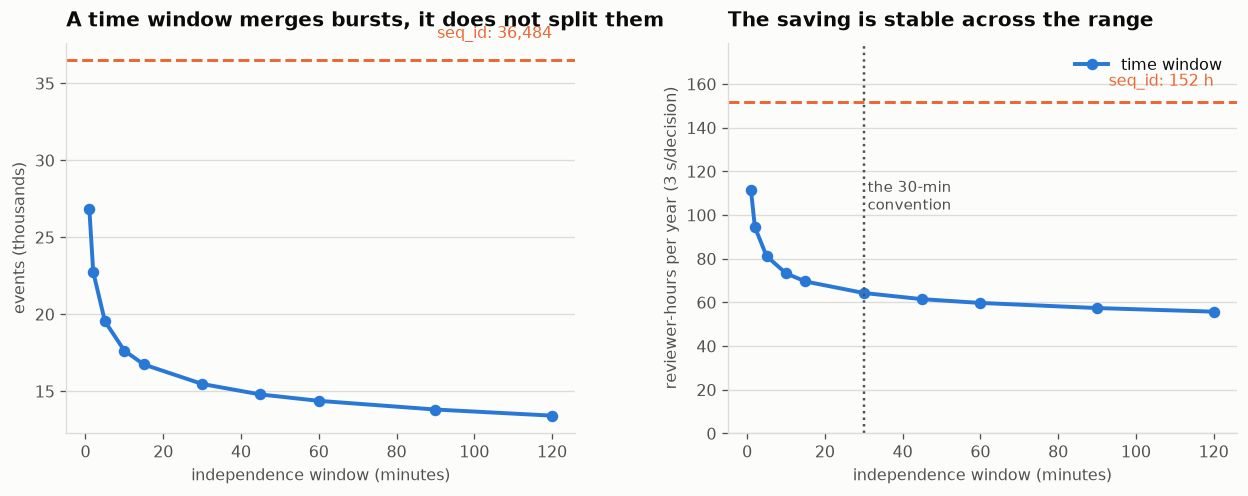

 window_min  events  frames_per_event  reviewer_h
          1   26808              7.57       111.0
          2   22742              8.93        95.0
          5   19544             10.39        81.0
         10   17635             11.51        73.0
         15   16740             12.13        70.0
         30   15473             13.12        64.0
         45   14791             13.73        61.0
         60   14376             14.12        60.0
         90   13812             14.70        57.0
        120   13415             15.13        56.0

seq_id: 36,484 events, 5.56 frames/event, 152 h


**Finding.** A time window produces **fewer** events than `seq_id`, not more: at 30 minutes it yields 15,473 events against 36,484 sequences, because it merges several consecutive bursts of the same species into one detection. Frames per event runs from 7.6 at a 1-minute window to 15.1 at two hours, and the resulting reviewer load only moves between 56 and 111 hours — **the conclusion is stable across the whole sweep**. **Design decision: use `seq_id` as the unit of work.** It is shipped with the dataset, it is defined by camera firmware rather than by an analyst's choice of constant, and it is the most conservative option — it claims the smallest saving of any definition tested. The 30-minute rule stays available for *ecological* reporting in S3.5, where independence between detections is what matters.

In [ ]:
ordered = df.sort_values(['location', 'y', 'datetime'])
gaps = ordered.groupby(['location', 'y'], observed=True).datetime.diff().dt.total_seconds()
windows = np.array([1, 2, 5, 10, 15, 30, 45, 60, 90, 120])
ev_counts = np.array([(gaps.isna() | (gaps > w * 60)).sum() for w in windows])
fpe = len(df) / ev_counts
hours = karr_year / fpe * 3 / 3600
seq_fpe, seq_hours = seq_frames, karr_year / seq_frames * 3 / 3600

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
ax.plot(windows, ev_counts / 1000, color=BLUE, lw=2.4, marker='o', ms=6)
ax.axhline(df.seq_id.nunique() / 1000, color=ORANGE, ls='--', lw=1.8)
ax.text(120, df.seq_id.nunique() / 1000 * 1.04, f'seq_id: {df.seq_id.nunique():,}',
        ha='right', fontsize=9.5, color=ORANGE)
ax.set_xlabel('independence window (minutes)'); ax.set_ylabel('events (thousands)')
ax.grid(axis='x', visible=False)
ax.set_title('A time window merges bursts, it does not split them')

ax2.plot(windows, hours, color=BLUE, lw=2.4, marker='o', ms=6, label='time window')
ax2.axhline(seq_hours, color=ORANGE, ls='--', lw=1.8)
ax2.text(120, seq_hours * 1.05, f'seq_id: {seq_hours:,.0f} h', ha='right',
         fontsize=9.5, color=ORANGE)
ax2.axvline(30, color=INK2, ls=':', lw=1.5)
ax2.text(31, hours.max() * .92, 'the 30-min\nconvention', fontsize=9, color=INK2)
ax2.set_xlabel('independence window (minutes)')
ax2.set_ylabel('reviewer-hours per year (3 s/decision)')
ax2.set_ylim(0, max(hours.max(), seq_hours) * 1.18)
ax2.grid(axis='x', visible=False); ax2.legend(loc='upper right')
ax2.set_title('The saving is stable across the range')
finish(fig, 's1_5_window'); plt.show()

print(pd.DataFrame({'window_min': windows, 'events': ev_counts,
                    'frames_per_event': fpe.round(2),
                    'reviewer_h': hours.round(0)}).to_string(index=False))
print(f"\nseq_id: {df.seq_id.nunique():,} events, {seq_frames:.2f} frames/event, "
      f"{seq_hours:,.0f} h")

finding(f'''
A time window produces **fewer** events than `seq_id`, not more: at 30 minutes it yields
{ev_counts[list(windows).index(30)]:,} events against {df.seq_id.nunique():,} sequences, because it
merges several consecutive bursts of the same species into one detection. Frames per event runs
from {fpe[0]:.1f} at a 1-minute window to {fpe[-1]:.1f} at two hours, and the resulting reviewer
load only moves between {hours.min():,.0f} and {hours.max():,.0f} hours — **the conclusion is
stable across the whole sweep**. **Design decision: use `seq_id` as the unit of work.** It is
shipped with the dataset, it is defined by camera firmware rather than by an analyst's choice of
constant, and it is the most conservative option — it claims the smallest saving of any definition
tested. The 30-minute rule stays available for *ecological* reporting in S3.5, where independence
between detections is what matters.
''')

---
# S2 · Targets

## S2.1 — How many species are there, and how many photographs does each have?

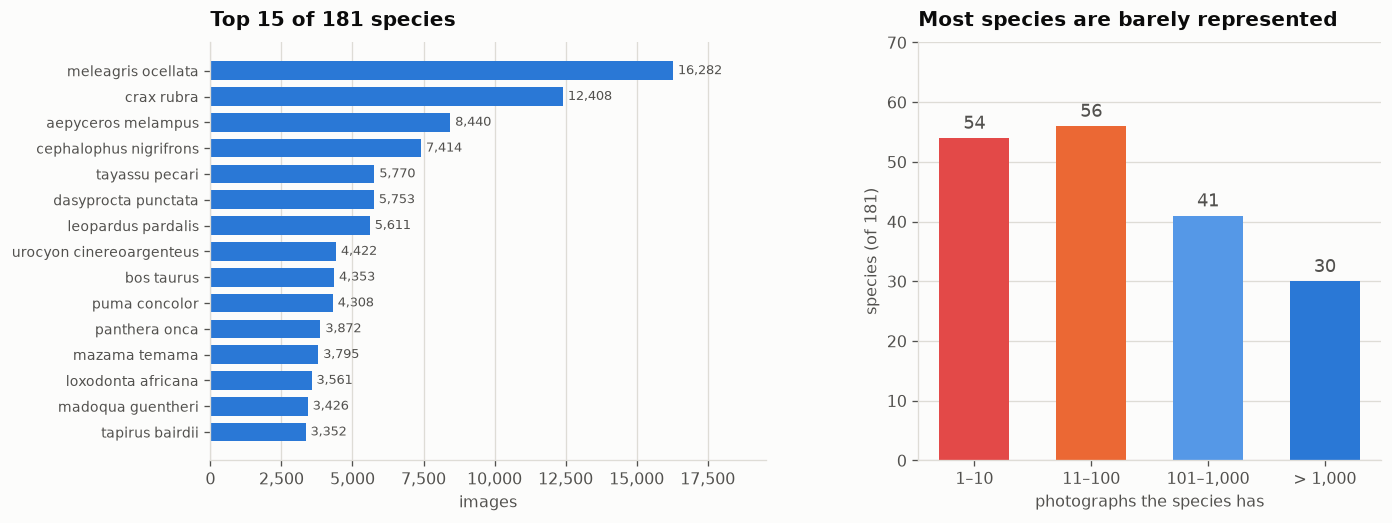

     images                   species
y                                    
146   16282        meleagris ocellata
147   12408                crax rubra
36     8440        aepyceros melampus
116    7414    cephalophus nigrifrons
1      5770            tayassu pecari
2      5753       dasyprocta punctata
8      5611        leopardus pardalis
145    4422  urocyon cinereoargenteus

species: 181 | blank images: 69,487 (34.2% of the dataset)
single-photo species: 8 | <=10: 54 | <=100: 110


**Finding.** **181 species**, and the distribution is brutal. The commonest, *meleagris ocellata*, has **16,282 images — 8.0% of the whole dataset** — while **54 species have ten photographs or fewer** and 8 have exactly one. Add the blank class at 34.2% and a single label accounts for a third of everything. **Design consequence: the headline metric cannot be accuracy.** A model that ignores every species below the top ten still scores well on accuracy and terribly on macro F1, which is exactly why the benchmark ranks on macro F1 and why Success Criterion 1 asks for per-species numbers. S2.2 sets the final class list and S4.4 shows how many of these species survive into the test split at all.

In [ ]:
sp = (df[~df.is_blank].y.value_counts().rename('images').to_frame()
        .assign(species=lambda d: d.index.map(name_of)))
sp_named = sp.set_index('species')['images']

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.6),
                              gridspec_kw={'width_ratios': [1.2, 1]})
top = sp_named.head(15).iloc[::-1]
b = ax.barh(range(len(top)), top.values, color=BLUE, height=.72)
ax.set_yticks(range(len(top)), top.index, fontsize=8.5)
ax.bar_label(b, labels=[f"{v:,}" for v in top.values], fontsize=8, color=INK2, padding=3)
ax.set_xlim(0, top.max() * 1.2); ax.xaxis.set_major_formatter(thousands)
ax.grid(axis='y', visible=False); ax.set_xlabel('images')
ax.set_title(f'Top 15 of {len(sp_named)} species')

bands = pd.Series({'1–10': int((sp_named <= 10).sum()),
                   '11–100': int(((sp_named > 10) & (sp_named <= 100)).sum()),
                   '101–1,000': int(((sp_named > 100) & (sp_named <= 1000)).sum()),
                   '> 1,000': int((sp_named > 1000).sum())})
b2 = ax2.bar(range(4), bands.values, color=[RED, ORANGE, SEQ[5], BLUE], width=.6)
ax2.bar_label(b2, fmt='%d', fontsize=11, color=INK2, padding=3)
ax2.set_xticks(range(4), bands.index, fontsize=9.5)
ax2.set_xlabel('photographs the species has')
ax2.set_ylabel(f'species (of {len(sp_named)})'); ax2.set_ylim(0, bands.max() * 1.25)
ax2.grid(axis='x', visible=False)
ax2.set_title('Most species are barely represented')
finish(fig, 's2_1_species'); plt.show()

print(sp.head(8).to_string())
print(f"\nspecies: {len(sp_named)} | blank images: {int(df.is_blank.sum()):,} "
      f"({df.is_blank.mean():.1%} of the dataset)")
print(f"single-photo species: {int((sp_named == 1).sum())} | <=10: {int((sp_named <= 10).sum())} "
      f"| <=100: {int((sp_named <= 100).sum())}")

finding(f'''
**{len(sp_named)} species**, and the distribution is brutal. The commonest,
*{sp_named.index[0]}*, has **{sp_named.iloc[0]:,} images — {sp_named.iloc[0]/len(df):.1%} of the
whole dataset** — while **{int((sp_named <= 10).sum())} species have ten photographs or fewer** and
{int((sp_named == 1).sum())} have exactly one. Add the blank class at {df.is_blank.mean():.1%} and
a single label accounts for a third of everything. **Design consequence: the headline metric cannot
be accuracy.** A model that ignores every species below the top ten still scores well on accuracy
and terribly on macro F1, which is exactly why the benchmark ranks on macro F1 and why Success
Criterion 1 asks for per-species numbers. S2.2 sets the final class list and S4.4 shows how many of
these species survive into the test split at all.
''')

## S2.2 — Label vocabulary hygiene: what are the classes, really?

182 classes is the headline. Before committing a classifier to it, the vocabulary needs auditing
for catch-all labels, mixed taxonomic levels, and entries that are not species at all.

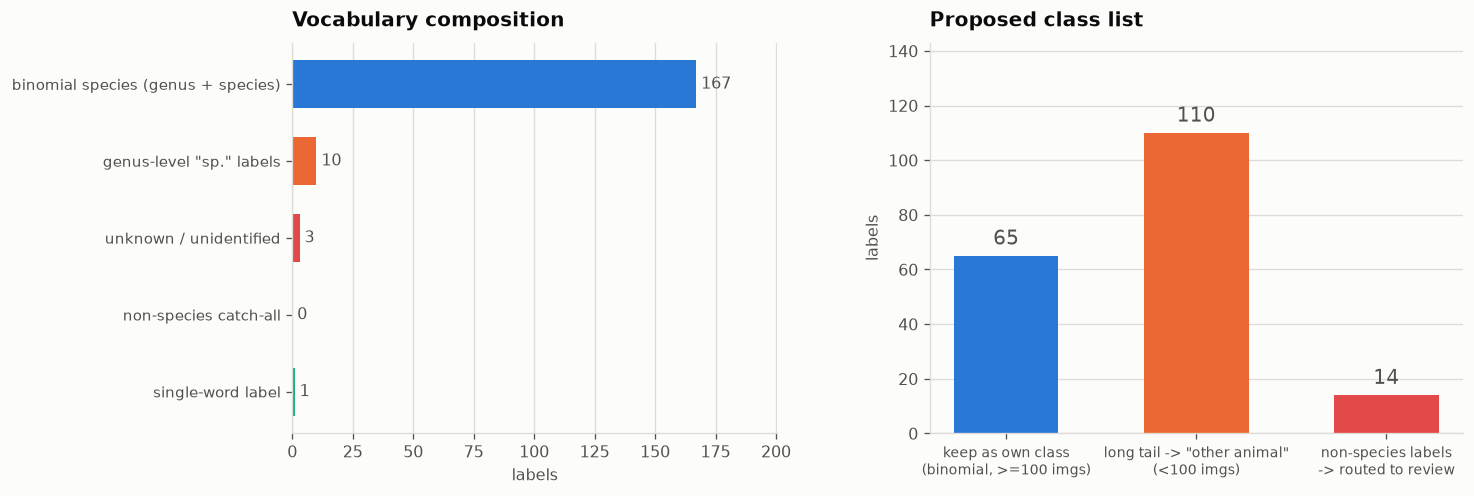

non-binomial labels found:
['didelphis sp', 'motorcycle', 'macaca sp', 'sciurus sp', 'peromyscus sp', 'unknown bird', 'mazama sp', 'unknown dove', 'unknown bat', 'lophura sp', 'geotrygon sp', 'brotogeris sp', 'tragulus sp', 'phaetornis sp']

classes kept: 65 | they cover 94.2% of animal images


**Finding.** The vocabulary is not 181 clean species. It contains **10 genus-level `sp.` labels** and 0 non-species catch-alls, which sit at a different taxonomic level from the rest — a model cannot be simultaneously right about *"didelphis sp"* and *"didelphis marsupialis"*, and scoring them as separate classes punishes it for a labelling artefact rather than an error. **Stated class list for this project: 65 binomial species with at least 100 images each, covering 94.2% of all animal photographs, plus `empty`, plus a single `other animal` class absorbing the 110 rare labels.** The rare class is not thrown away — it becomes the alert queue in S5.3, where "an animal we cannot name" is the output a ranger actually needs. Report macro F1 over the stated list and publish the mapping alongside it, so the number is reproducible and comparable.

In [ ]:
names = pd.Series(sp_named.index, index=sp_named.index)
n_words = names.str.split().str.len()
is_genus_sp = names.str.contains(r'\bsp\.?$', case=False, regex=True)
is_unknown  = names.str.contains(r'unknown|unidentified', case=False)
is_generic  = names.isin(['empty']) | names.str.fullmatch(
    r'(bird|mammal|rodent|reptile|insect|animal)', case=False, na=False)
non_binomial = is_genus_sp | is_unknown | is_generic | (n_words < 2)

audit_tbl = pd.DataFrame({
    'category': ['binomial species (genus + species)', 'genus-level "sp." labels',
                 'unknown / unidentified', 'non-species catch-all', 'single-word label'],
    'count': [int((~non_binomial).sum()), int(is_genus_sp.sum()), int(is_unknown.sum()),
              int(is_generic.sum()), int((n_words < 2).sum())]})

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3),
                              gridspec_kw={'width_ratios': [1, 1.1]})
b = ax.barh(range(len(audit_tbl)), audit_tbl['count'],
            color=[BLUE, ORANGE, RED, VIOLET, AQUA], height=.62)
ax.set_yticks(range(len(audit_tbl)), audit_tbl.category, fontsize=9)
ax.bar_label(b, fmt='%d', fontsize=10, color=INK2, padding=3)
ax.set_xlim(0, audit_tbl['count'].max() * 1.2); ax.invert_yaxis()
ax.grid(axis='y', visible=False); ax.set_xlabel('labels')
ax.set_title('Vocabulary composition')

keep_mask = (~non_binomial) & (sp_named >= 100)
plan = pd.Series({
    'keep as own class\n(binomial, >=100 imgs)': int(keep_mask.sum()),
    'long tail -> "other animal"\n(<100 imgs)': int((sp_named < 100).sum()),
    'non-species labels\n-> routed to review': int(non_binomial.sum()),
})
b2 = ax2.bar(range(3), plan.values, color=[BLUE, ORANGE, RED], width=.55)
ax2.bar_label(b2, fmt='%d', fontsize=12, color=INK2, padding=4)
ax2.set_xticks(range(3), plan.index, fontsize=8.5)
ax2.set_ylabel('labels'); ax2.set_ylim(0, plan.max() * 1.3)
ax2.grid(axis='x', visible=False)
ax2.set_title('Proposed class list')
finish(fig, 's2_2_vocabulary'); plt.show()

print("non-binomial labels found:")
print(names[non_binomial].tolist())
covered = sp_named[keep_mask].sum() / sp_named.sum()
print(f"\nclasses kept: {int(keep_mask.sum())} | they cover {covered:.1%} of animal images")

finding(f'''
The vocabulary is not {len(sp_named)} clean species. It contains
**{int(is_genus_sp.sum())} genus-level `sp.` labels** and {int(is_generic.sum())} non-species
catch-alls, which sit at a different taxonomic level from the rest — a model cannot be simultaneously
right about *"didelphis sp"* and *"didelphis marsupialis"*, and scoring them as separate classes
punishes it for a labelling artefact rather than an error. **Stated class list for this project:
{int(keep_mask.sum())} binomial species with at least 100 images each, covering {covered:.1%} of all
animal photographs, plus `empty`, plus a single `other animal` class absorbing the
{int((sp_named < 100).sum())} rare labels.** The rare class is not thrown away — it becomes the
alert queue in S5.3, where "an animal we cannot name" is the output a ranger actually needs. Report
macro F1 over the stated list and publish the mapping alongside it, so the number is reproducible
and comparable.
''')

## S2.3 — When is each species active?

The deck promises a diel-activity breakdown including a **crepuscular** category, so the cut is
three-way rather than the usual binary night/day.

C:\Users\Admin\AppData\Local\Temp\ipykernel_11532\3894664580.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cls = pd.DataFrame({'night': hn[NIGHT].sum(1), 'crepuscular': hn[CREP].sum(1),
C:\Users\Admin\AppData\Local\Temp\ipykernel_11532\3894664580.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cls = pd.DataFrame({'night': hn[NIGHT].sum(1), 'crepuscular': hn[CREP].sum(1),
C:\Users\Admin\AppData\Local\Temp\ipykernel_11532\3894664580.py:10: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  'day': hn[DAY].sum(1)})


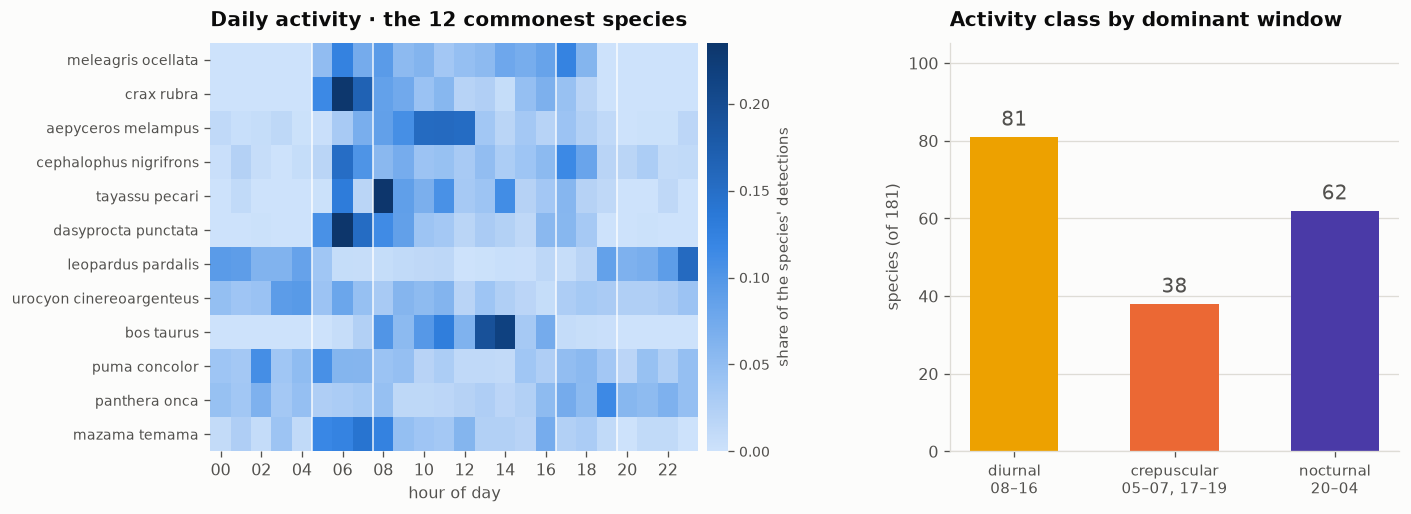

                 species  images  night  crepuscular   day       label
      meleagris ocellata   16282  0.000        0.427 0.573         day
              crax rubra   12408  0.000        0.576 0.424 crepuscular
      aepyceros melampus    8440  0.056        0.179 0.765         day
  cephalophus nigrifrons    7414  0.103        0.484 0.413 crepuscular
          tayassu pecari    5770  0.023        0.242 0.736         day
     dasyprocta punctata    5753  0.003        0.585 0.412 crepuscular
      leopardus pardalis    5611  0.773        0.160 0.068       night
urocyon cinereoargenteus    4422  0.436        0.256 0.308       night
              bos taurus    4353  0.000        0.045 0.955         day
           puma concolor    4308  0.405        0.364 0.231       night
           panthera onca    3872  0.446        0.329 0.225       night
           mazama temama    3795  0.114        0.445 0.441 crepuscular

{'day': 81, 'crepuscular': 38, 'night': 62}


**Finding.** Splitting the clock three ways separates the species far better than a binary cut would: **81 diurnal, 38 crepuscular, 62 nocturnal**. The crepuscular group is not a rounding artefact — species like *crax rubra* put a genuine majority of their detections into the dawn and dusk bands, and a night/day cut would split that signal in half and assign it arbitrarily. **Design consequence: hour-of-day is a free, always-available feature and belongs in the model**, and the same three-way cut should drive the reporting dashboard. One caveat to carry: these are local camera clocks across several continents with no timezone normalisation, so the bands are approximate — and S4.3 shows the infrared flag is a more reliable indicator of *actual* darkness than the clock is.

In [ ]:
NIGHT = [20, 21, 22, 23, 0, 1, 2, 3, 4]
CREP  = [5, 6, 7, 17, 18, 19]
DAY   = [8, 9, 10, 11, 12, 13, 14, 15, 16]

w = df[~df.is_blank]
hh = (w.groupby(['y', 'hour'], observed=True).size().unstack(fill_value=0)
        .reindex(columns=range(24), fill_value=0))
hn = hh.div(hh.sum(axis=1), axis=0)
cls = pd.DataFrame({'night': hn[NIGHT].sum(1), 'crepuscular': hn[CREP].sum(1),
                    'day': hn[DAY].sum(1)})
cls['label'] = cls.idxmax(axis=1)
cls['images'] = w.y.value_counts().reindex(cls.index)
cls['species'] = [name_of.get(i) for i in cls.index]

top12 = cls.nlargest(12, 'images')
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.0, 4.5),
                              gridspec_kw={'width_ratios': [1.3, 1]})
im = ax.imshow(hn.loc[top12.index].values, cmap=CMAP, aspect='auto')
ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.set_yticks(range(len(top12)), top12.species, fontsize=8.5)
ax.set_xlabel('hour of day'); ax.grid(False)
for s_ in ax.spines.values():
    s_.set_visible(False)
for edge in (4.5, 7.5, 16.5, 19.5):
    ax.axvline(edge, color='white', lw=1.2, alpha=.7)
cb = fig.colorbar(im, ax=ax, pad=.015); cb.outline.set_visible(False)
cb.set_label("share of the species' detections", fontsize=9); cb.ax.tick_params(labelsize=8.5)
ax.set_title('Daily activity · the 12 commonest species')

counts = cls.label.value_counts().reindex(['day', 'crepuscular', 'night']).fillna(0)
b = ax2.bar(range(3), counts.values, color=[YELLOW, ORANGE, VIOLET], width=.55)
ax2.bar_label(b, fmt='%d', fontsize=12, color=INK2, padding=4)
ax2.set_xticks(range(3), ['diurnal\n08–16', 'crepuscular\n05–07, 17–19', 'nocturnal\n20–04'],
               fontsize=9)
ax2.set_ylabel(f'species (of {len(cls)})'); ax2.set_ylim(0, counts.max() * 1.3)
ax2.grid(axis='x', visible=False)
ax2.set_title('Activity class by dominant window')
finish(fig, 's2_3_diel'); plt.show()

print(top12[['species', 'images', 'night', 'crepuscular', 'day', 'label']].round(3).to_string(index=False))
print(f"\n{counts.to_dict()}")

finding(f'''
Splitting the clock three ways separates the species far better than a binary cut would:
**{int(counts['day'])} diurnal, {int(counts['crepuscular'])} crepuscular,
{int(counts['night'])} nocturnal**. The crepuscular group is not a rounding artefact — species like
*{cls[cls.label=='crepuscular'].nlargest(1,'images').species.iloc[0]}* put a genuine majority of
their detections into the dawn and dusk bands, and a night/day cut would split that signal in half
and assign it arbitrarily. **Design consequence: hour-of-day is a free, always-available feature
and belongs in the model**, and the same three-way cut should drive the reporting dashboard. One
caveat to carry: these are local camera clocks across several continents with no timezone
normalisation, so the bands are approximate — and S4.3 shows the infrared flag is a more reliable
indicator of *actual* darkness than the clock is.
''')

## S2.4 — Seasonal structure and calendar coverage

The dataset spans nearly three years. Whether that is usable for seasonality depends on how evenly
it is covered — and on whether cameras run concurrently or in sequence.

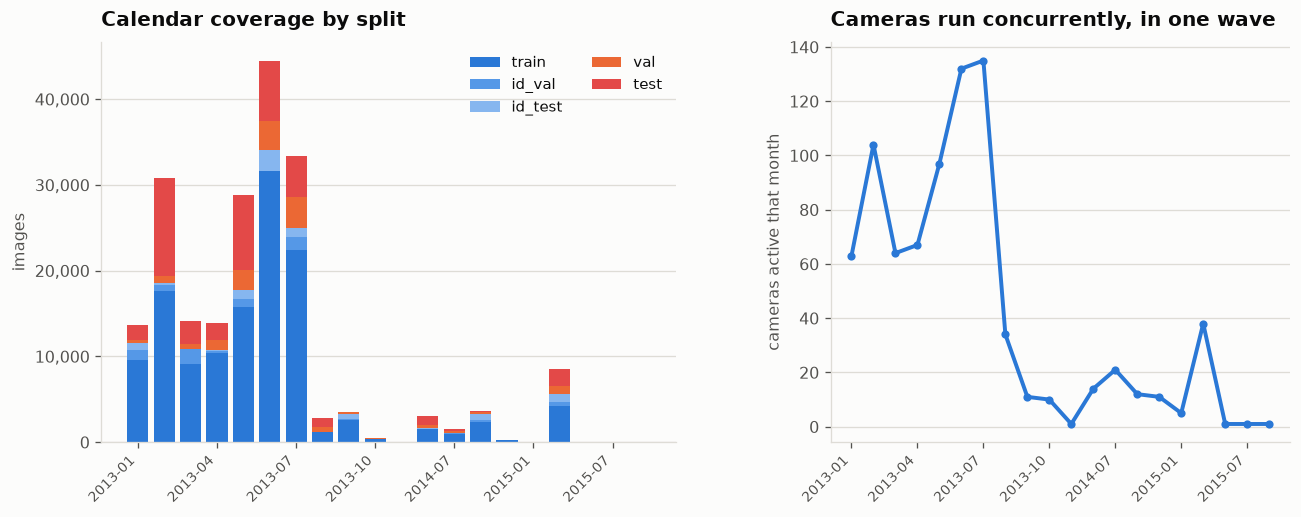

          images   pct
datetime              
2013      186041  91.6
2014        8472   4.2
2015        8516   4.2

months covered: 20 | cameras active in >1 month: 255 of 323
median months per camera: 2 | peak concurrency: 135 cameras in 2013-07


**Finding.** The three-year span is an illusion. **92% of the images fall in 2013**, the remaining two years contribute a few percent each, and several months are empty. Cameras also run in one concurrent wave rather than a rolling programme — peak concurrency is **135 cameras in 2013-07**, and the median camera is active in only 2 months. **Design consequence: do not model seasonality and do not feed `month` or `year` to the classifier.** In this dataset the calendar encodes *which field campaign was running*, which correlates with location, which correlates with species — a shortcut that will inflate validation and collapse on new cameras. Hour-of-day (S2.3) is the temporal feature that survives, because it is measured within a camera rather than across the programme. For KARR this also means the transfer plan cannot assume seasonal coverage it has never observed.

In [ ]:
by_month = df.groupby(['month', 'split'], observed=True).size().unstack(fill_value=0)
by_month = by_month.reindex(columns=[c for c in SPLIT_ORDER if c in by_month.columns])

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.0, 4.4),
                              gridspec_kw={'width_ratios': [1.25, 1]})
bottom = np.zeros(len(by_month))
cols = {'train': BLUE, 'id_val': SEQ[5], 'id_test': SEQ[3], 'val': ORANGE, 'test': RED}
xs = np.arange(len(by_month))
for c in by_month.columns:
    ax.bar(xs, by_month[c], bottom=bottom, color=cols[c], width=.8, label=c)
    bottom += by_month[c].values
ax.set_xticks(xs[::3], [str(p) for p in by_month.index][::3], rotation=45, ha='right', fontsize=8.5)
ax.set_ylabel('images'); ax.yaxis.set_major_formatter(thousands)
ax.grid(axis='x', visible=False); ax.legend(loc='upper right', fontsize=9, ncols=2)
ax.set_title('Calendar coverage by split')

cam_months = df.groupby('location').month.nunique()
active_per_month = df.groupby('month', observed=True).location.nunique()
ax2.plot(xs, active_per_month.reindex(by_month.index).values, color=BLUE, lw=2.4,
         marker='o', ms=4)
ax2.set_xticks(xs[::3], [str(p) for p in by_month.index][::3], rotation=45, ha='right', fontsize=8.5)
ax2.set_ylabel('cameras active that month')
ax2.grid(axis='x', visible=False)
ax2.set_title('Cameras run concurrently, in one wave')
finish(fig, 's2_4_seasonal'); plt.show()

yr = df.datetime.dt.year.value_counts().sort_index()
print(yr.rename('images').to_frame().assign(
    pct=lambda d: (d.images / len(df) * 100).round(1)).to_string())
print(f"\nmonths covered: {df.month.nunique()} | cameras active in >1 month: "
      f"{int((cam_months > 1).sum())} of {df.location.nunique()}")
print(f"median months per camera: {cam_months.median():.0f} | peak concurrency: "
      f"{active_per_month.max()} cameras in {active_per_month.idxmax()}")

finding(f'''
The three-year span is an illusion. **{yr.iloc[0]/len(df):.0%} of the images fall in
{yr.index[0]}**, the remaining two years contribute a few percent each, and several months are
empty. Cameras also run in one concurrent wave rather than a rolling programme — peak concurrency
is **{active_per_month.max()} cameras in {active_per_month.idxmax()}**, and the median camera is
active in only {cam_months.median():.0f} months. **Design consequence: do not model seasonality and
do not feed `month` or `year` to the classifier.** In this dataset the calendar encodes *which
field campaign was running*, which correlates with location, which correlates with species — a
shortcut that will inflate validation and collapse on new cameras. Hour-of-day (S2.3) is the
temporal feature that survives, because it is measured within a camera rather than across the
programme. For KARR this also means the transfer plan cannot assume seasonal coverage it has never
observed.
''')

## S2.5 — How large is the animal in the frame?

This decides crop-versus-full-frame, input resolution, and whether the task is really detection
rather than classification. **S0.1 established that this release ships no bounding boxes**, so the
direct measurement is impossible.

An indirect one is available. Within a burst the camera, framing and lighting are fixed, so a blank
frame from the same sequence is a clean background plate; the pixels that differ in an animal frame
estimate the animal's footprint. That is computed here over sequences containing both, with the
burned-in banners (S4.6) excluded from the comparison.

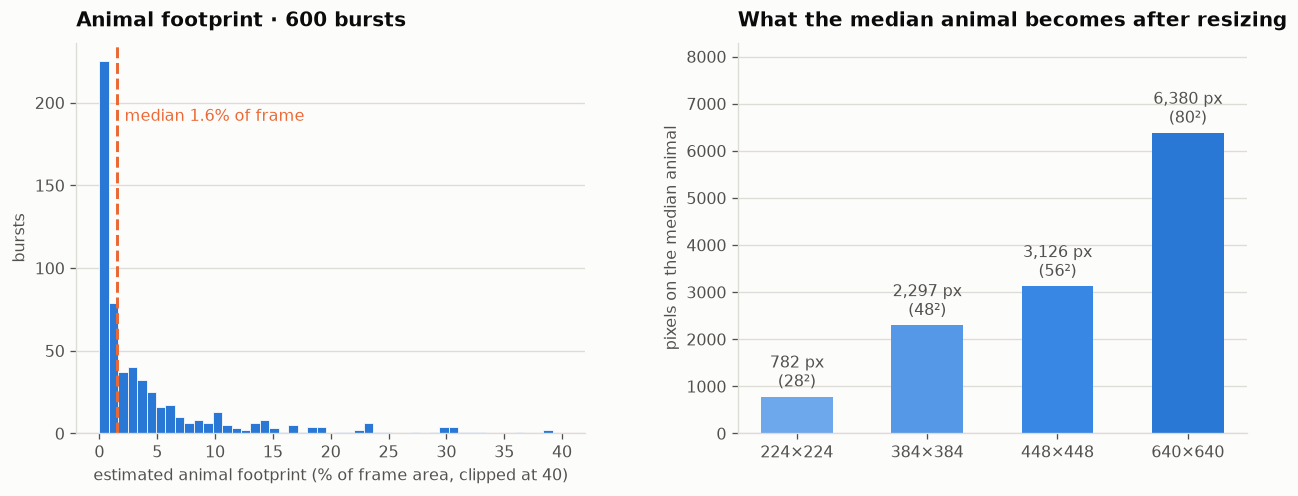

count    600.0000
mean       0.0590
std        0.1196
min        0.0000
10%        0.0003
25%        0.0028
50%        0.0156
75%        0.0548
90%        0.1518
max        0.9399

bursts where the estimate is under 1% of frame: 41.7%


**Finding.** **No bounding boxes ship with this release**, so animal scale is formally an unknown going into model design — and any detection work would need new labels. The background-subtraction estimate says the unknown is not a comfortable one: the **median animal occupies about 1.6% of the frame**, the lower quartile 0.3%, and **42% of bursts put it under 1%**. Resized to a 224×224 CNN input that median animal is roughly 28×28 pixels. **Design consequence: whole-frame classification at standard input resolution is the wrong architecture.** Either run a detector first and classify crops — which is what MegaDetector exists for and what the original iWildCam competition supplied boxes for — or train at substantially higher input resolution and accept the cost. Treat this as an estimate: it counts shadow and vegetation movement as well as the animal, so it is an upper bound on footprint, which makes the conclusion stronger rather than weaker.

In [ ]:
fg_path = CACHE / "foreground.csv"
if fg_path.exists():
    fg = pd.read_csv(fg_path)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
    ax.hist(fg.fg_frac * 100, bins=np.linspace(0, 40, 50), color=BLUE,
            edgecolor=SURFACE, linewidth=.5)
    med = fg.fg_frac.median() * 100
    ax.axvline(med, color=ORANGE, ls='--', lw=1.8)
    ax.text(med * 1.4, ax.get_ylim()[1] * .8, f'median {med:.1f}% of frame',
            fontsize=9.5, color=ORANGE)
    ax.set_xlabel('estimated animal footprint (% of frame area, clipped at 40)')
    ax.set_ylabel('bursts'); ax.grid(axis='x', visible=False)
    ax.set_title(f'Animal footprint · {len(fg)} bursts')

    px_at = {r: fg.fg_frac.median() * r * r for r in (224, 384, 448, 640)}
    b = ax2.bar(range(len(px_at)), list(px_at.values()), color=SEQ[4:8], width=.55)
    ax2.bar_label(b, labels=[f"{v:,.0f} px\n({np.sqrt(v):.0f}²)" for v in px_at.values()],
                  fontsize=9.5, color=INK2, padding=3)
    ax2.set_xticks(range(len(px_at)), [f"{r}×{r}" for r in px_at], fontsize=10)
    ax2.set_ylabel('pixels on the median animal'); ax2.set_ylim(0, max(px_at.values()) * 1.3)
    ax2.grid(axis='x', visible=False)
    ax2.set_title('What the median animal becomes after resizing')
    finish(fig, 's2_5_animal_size'); plt.show()

    q25 = float(fg.fg_frac.quantile(.25))
    print(fg.fg_frac.describe(percentiles=[.1, .25, .5, .75, .9]).round(4).to_string())
    print(f"\nbursts where the estimate is under 1% of frame: {(fg.fg_frac < .01).mean():.1%}")

    finding(f'''
    **No bounding boxes ship with this release**, so animal scale is formally an unknown going into
    model design — and any detection work would need new labels. The background-subtraction estimate
    says the unknown is not a comfortable one: the **median animal occupies about
    {med:.1f}% of the frame**, the lower quartile {q25*100:.1f}%, and
    **{(fg.fg_frac < .01).mean():.0%} of bursts put it under 1%**. Resized to a 224×224 CNN input
    that median animal is roughly {np.sqrt(px_at[224]):.0f}×{np.sqrt(px_at[224]):.0f} pixels.
    **Design consequence: whole-frame classification at standard input resolution is the wrong
    architecture.** Either run a detector first and classify crops — which is what MegaDetector
    exists for and what the original iWildCam competition supplied boxes for — or train at
    substantially higher input resolution and accept the cost. Treat this as an estimate: it counts
    shadow and vegetation movement as well as the animal, so it is an upper bound on footprint, which
    makes the conclusion stronger rather than weaker.
    ''')
else:
    print("cache/foreground.csv not found - run scripts/build_fg.py to generate it")
    finding('''
    **No bounding boxes ship with this release.** Animal scale in frame is therefore an unknown
    going into model design, and no detection work is possible without commissioning new labels.
    ''')

---
# S3 · Stations

## S3.1 — Effort, activity and coverage per camera

Effort is the denominator of every abundance figure, so its definition and its bias both need
stating. iWildCam ships no deployment windows, so **active days** — distinct dates with at least
one image — stands in for them.

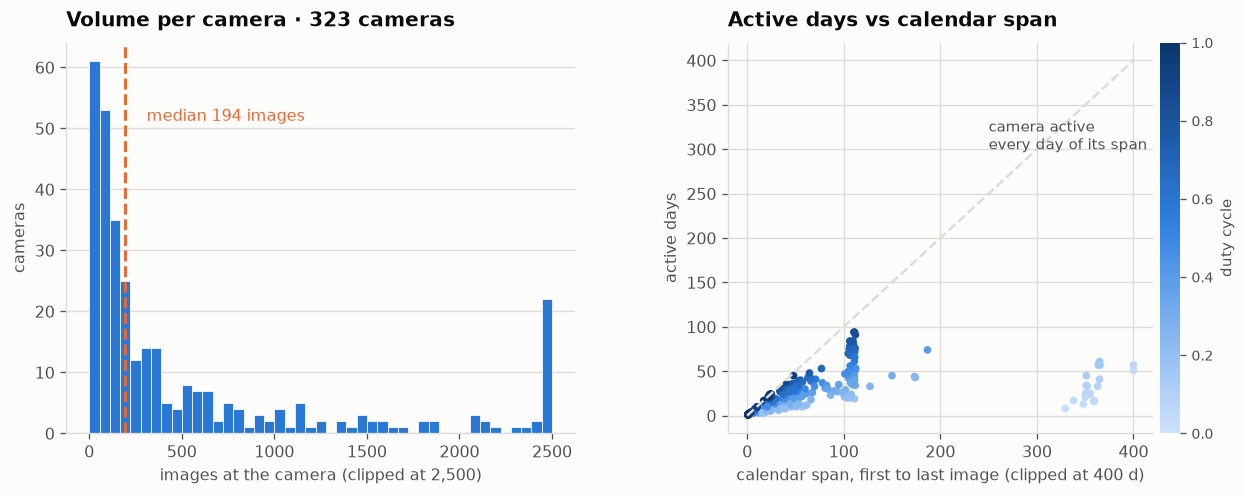

        images  active_days  span_days    duty   blank  species
count   323.00       323.00     323.00  323.00  323.00   323.00
mean    628.57        23.34      68.56    0.55    0.41     7.25
std    1058.42        18.21     104.08    0.28    0.41     4.90
min       1.00         1.00       1.00    0.02    0.00     1.00
25%      74.50        12.00      22.57    0.33    0.01     4.00
50%     194.00        20.00      41.73    0.53    0.22     6.00
75%     643.00        30.00      65.23    0.74    0.86    10.00
max    8494.00        94.00    1012.70    1.91    1.00    24.00

total active camera-days : 7,538
cameras under 100 images : 104 of 323 (32%)
busiest camera           : loc 501 with 8,494 images
duty cycle               : median 0.53, lower quartile 0.33


**Finding.** Effort is wildly uneven: the median camera contributed **194 images** and the busiest **8,494**, while **104 of 323 cameras (32%) have fewer than 100 images** — too little to say anything about that station. The approximation's bias is visible in the right-hand panel: the median camera is active on only **53% of the days between its first and last image**, so a camera that was powered on but quiet is undercounted and its RAI is correspondingly overstated. Two things bound that error. First, 34% of frames are blanks, and blanks fire on wind and heat all day, so a running camera almost always produces *something* — a truly silent day is more likely a dead camera than a quiet one. Second, the effect is one-directional and shared across cameras, so it biases levels more than rankings. **Design consequence: the dashboard must gate on effort** — report no abundance figure for a camera below a stated minimum active-day count, and show the count beside every rate.

In [ ]:
cam = df.groupby('location').agg(
    images=('image_id', 'size'), active_days=('date', 'nunique'),
    first=('datetime', 'min'), last=('datetime', 'max'),
    blank=('is_blank', 'mean'), species=('y', 'nunique'), seqs=('seq_id', 'nunique'))
cam['span_days'] = (cam['last'] - cam['first']).dt.total_seconds() / 86400 + 1
cam['duty'] = cam.active_days / cam.span_days

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
ax.hist(cam.images.clip(upper=2500), bins=45, color=BLUE, edgecolor=SURFACE, linewidth=.5)
ax.axvline(cam.images.median(), color=ORANGE, ls='--', lw=1.8)
ax.text(cam.images.median() * 1.6, ax.get_ylim()[1] * .8,
        f'median {cam.images.median():,.0f} images', fontsize=9.5, color=ORANGE)
ax.set_xlabel('images at the camera (clipped at 2,500)'); ax.set_ylabel('cameras')
ax.grid(axis='x', visible=False)
ax.set_title(f'Volume per camera · {len(cam)} cameras')

ax2.scatter(cam.span_days.clip(upper=400), cam.active_days, s=22, c=cam.duty,
            cmap=CMAP, vmin=0, vmax=1, edgecolor='none')
ax2.plot([0, 400], [0, 400], color=GRID, ls='--', lw=1.5)
ax2.text(250, 300, 'camera active\nevery day of its span', fontsize=9, color=INK2)
ax2.set_xlabel('calendar span, first to last image (clipped at 400 d)')
ax2.set_ylabel('active days')
sc = ax2.collections[0]
cb = fig.colorbar(sc, ax=ax2, pad=.015); cb.outline.set_visible(False)
cb.set_label('duty cycle', fontsize=9); cb.ax.tick_params(labelsize=8.5)
ax2.set_title('Active days vs calendar span')
finish(fig, 's3_1_effort'); plt.show()

print(cam[['images', 'active_days', 'span_days', 'duty', 'blank', 'species']]
      .describe(percentiles=[.25, .5, .75]).round(2).to_string())
thin_cams = int((cam.images < 100).sum())
print(f"\ntotal active camera-days : {int(cam.active_days.sum()):,}")
print(f"cameras under 100 images : {thin_cams} of {len(cam)} ({thin_cams/len(cam):.0%})")
print(f"busiest camera           : loc {cam.images.idxmax()} with {cam.images.max():,} images")
print(f"duty cycle               : median {cam.duty.median():.2f}, "
      f"lower quartile {cam.duty.quantile(.25):.2f}")

finding(f'''
Effort is wildly uneven: the median camera contributed **{cam.images.median():,.0f} images** and
the busiest **{cam.images.max():,}**, while **{thin_cams} of {len(cam)} cameras
({thin_cams/len(cam):.0%}) have fewer than 100 images** — too little to say anything about that station.
The approximation's bias is visible in the right-hand panel: the median camera is active on only
**{cam.duty.median():.0%} of the days between its first and last image**, so a camera that was
powered on but quiet is undercounted and its RAI is correspondingly overstated. Two things bound
that error. First, {df.is_blank.mean():.0%} of frames are blanks, and blanks fire on wind and heat
all day, so a running camera almost always produces *something* — a truly silent day is more likely
a dead camera than a quiet one. Second, the effect is one-directional and shared across cameras, so
it biases levels more than rankings. **Design consequence: the dashboard must gate on effort** —
report no abundance figure for a camera below a stated minimum active-day count, and show the count
beside every rate.
''')

## S3.2 — How many species does each camera see?

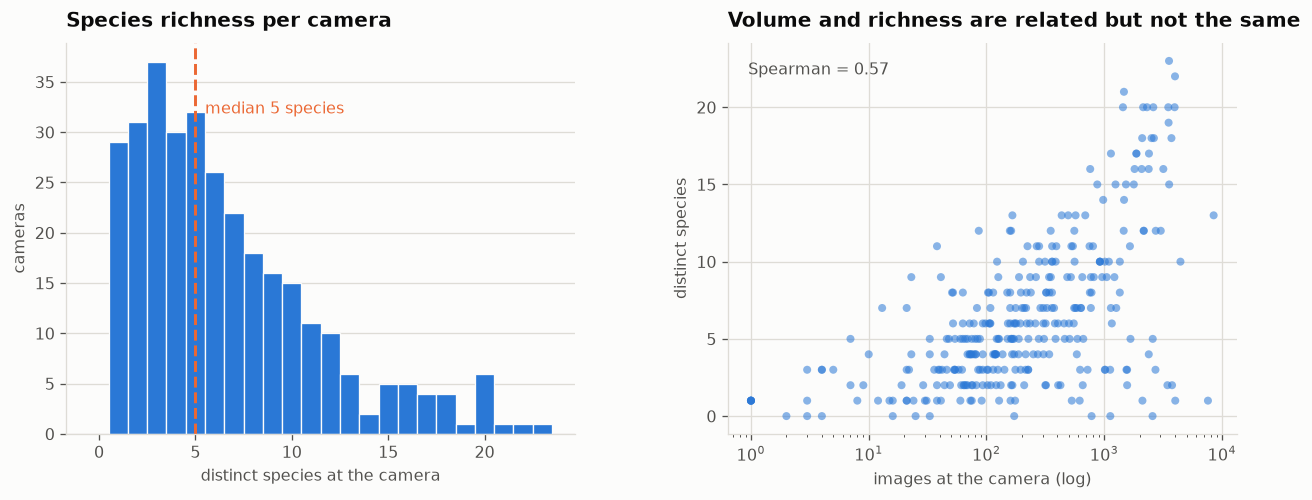

count    313.0
mean       6.6
std        4.8
min        1.0
25%        3.0
50%        5.0
75%        9.0
max       23.0

cameras seeing 1 species only: 29
richest camera: loc 512 with 23 species


**Finding.** A typical camera records **5 species**, the richest **23**, and 29 cameras recorded just one. Volume and richness correlate at Spearman 0.57 — related, but far from interchangeable: a camera on a busy trail can fire thousands of times at the same two animals. **Design consequence: the station report must carry both numbers.** Ranking stations by photograph count alone answers "where is there traffic", not "where is there biodiversity", and those are different operational questions for a reserve — one drives maintenance, the other drives conservation attention.

In [ ]:
rich = df[~df.is_blank].groupby('location').y.nunique()
joined = pd.DataFrame({'images': cam.images, 'species': rich}).fillna(0)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
ax.hist(rich.values, bins=range(0, int(rich.max()) + 2), color=BLUE,
        edgecolor=SURFACE, linewidth=.8, align='left')
ax.axvline(rich.median(), color=ORANGE, ls='--', lw=1.8)
ax.text(rich.median() + .5, ax.get_ylim()[1] * .82, f'median {rich.median():.0f} species',
        fontsize=9.5, color=ORANGE)
ax.set_xlabel('distinct species at the camera'); ax.set_ylabel('cameras')
ax.grid(axis='x', visible=False)
ax.set_title('Species richness per camera')

ax2.scatter(joined.images, joined.species, s=24, color=BLUE, alpha=.55, edgecolor='none')
ax2.set_xscale('log'); ax2.set_xlabel('images at the camera (log)')
ax2.set_ylabel('distinct species')
rho = joined.images.rank().corr(joined.species.rank())
ax2.text(.04, .92, f'Spearman = {rho:.2f}', transform=ax2.transAxes, fontsize=10, color=INK2)
ax2.set_title('Volume and richness are related but not the same')
finish(fig, 's3_2_richness'); plt.show()

print(rich.describe().round(1).to_string())
print(f"\ncameras seeing 1 species only: {int((rich == 1).sum())}")
print(f"richest camera: loc {rich.idxmax()} with {rich.max()} species")

finding(f'''
A typical camera records **{rich.median():.0f} species**, the richest **{rich.max()}**, and
{int((rich == 1).sum())} cameras recorded just one. Volume and richness correlate at Spearman
{rho:.2f} — related, but far from interchangeable: a camera on a busy trail can fire thousands of
times at the same two animals. **Design consequence: the station report must carry both numbers.**
Ranking stations by photograph count alone answers "where is there traffic", not "where is there
biodiversity", and those are different operational questions for a reserve — one drives
maintenance, the other drives conservation attention.
''')

## S3.3 — Does correcting for effort change which cameras look productive?

The deck's hardware-relocation signal depends on ranking stations by productivity. Raw image count
is the obvious ranking and the wrong one, because a camera that ran longer records more. The test
is whether dividing by effort actually reorders the list.

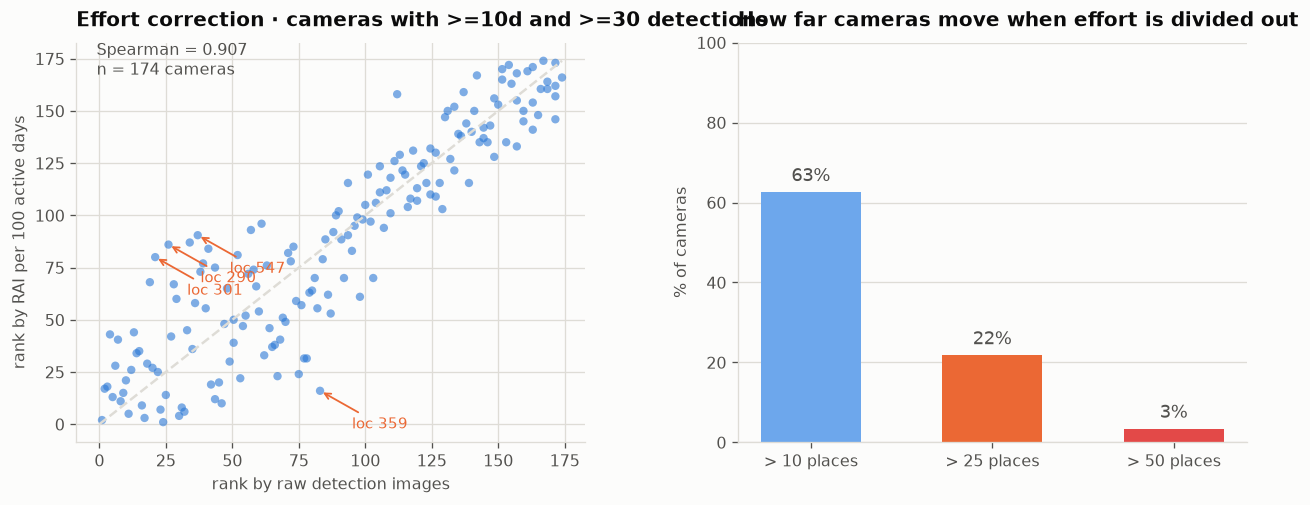

all 323 cameras            : Spearman 0.897
gated (10d, 30 det) n=174 : Spearman 0.907, median |shift| 14 places

biggest movers:
          det_imgs  events  active_days    RAI  rank_raw  rank_rai
location                                                          
359          333.0    71.0           12  591.7      83.0      16.0
290         1500.0   159.0           56  283.9      26.0      86.0
301         2010.0   203.0           68  298.5      21.0      80.0
547         1120.0   112.0           40  280.0      37.0      90.5
416         1220.0   173.0           61  283.6      34.0      87.0

cameras excluded by the effort gate: 149


**Finding.** Effort correction **reorders the middle of the table but not the top**. Among the 174 cameras with enough effort to judge, the two rankings correlate at **Spearman 0.907** — the median camera moves **14 places**, **22% move more than 25**, and the largest single move is rank 83 to 16. That is a weaker effect than a small-sample study would suggest, and the reason is visible in the data: frames per burst are fairly uniform across iWildCam's cameras, so raw counts are not as distorted here as they would be where animals linger. **Two design consequences.** The effort gate is not optional — without it, cameras with one or two active days produce RAI values in the thousands and dominate the ranking as pure artefact, which is why 149 cameras are excluded here. And for the relocation deliverable, **rank on RAI but present raw counts beside it**: the ranking disagreement is real for mid-table stations, which is exactly where a marginal relocation decision gets made.

In [ ]:
MIN_DAYS, MIN_DET = 10, 30
det = df[~df.is_blank].groupby('location').agg(det_imgs=('image_id', 'size'),
                                               events=('seq_id', 'nunique'))
rai = cam[['active_days']].join(det).fillna(0)
rai['RAI'] = rai.events / rai.active_days * 100
ok = rai[(rai.active_days >= MIN_DAYS) & (rai.det_imgs >= MIN_DET)].copy()
ok['rank_raw'] = ok.det_imgs.rank(ascending=False)
ok['rank_rai'] = ok.RAI.rank(ascending=False)
ok['shift'] = (ok.rank_raw - ok.rank_rai).abs()
rho_all = rai.det_imgs.rank(ascending=False).corr(rai.RAI.rank(ascending=False), method='spearman')
rho_ok = ok.rank_raw.corr(ok.rank_rai, method='spearman')

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.4))
ax.scatter(ok.rank_raw, ok.rank_rai, s=26, color=BLUE, alpha=.6, edgecolor='none')
ax.plot([0, len(ok)], [0, len(ok)], color=GRID, ls='--', lw=1.5)
big = ok.nlargest(4, 'shift')
for loc, r in big.iterrows():
    ax.annotate(f"loc {loc}", xy=(r.rank_raw, r.rank_rai),
                xytext=(r.rank_raw + 12, r.rank_rai - 18), fontsize=9, color=ORANGE,
                arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.1))
ax.set_xlabel('rank by raw detection images'); ax.set_ylabel('rank by RAI per 100 active days')
ax.text(.04, .92, f'Spearman = {rho_ok:.3f}\nn = {len(ok)} cameras',
        transform=ax.transAxes, fontsize=10, color=INK2)
ax.set_title(f'Effort correction · cameras with >={MIN_DAYS}d and >={MIN_DET} detections')

moves = pd.Series({'> 10 places': (ok['shift'] > 10).mean(),
                   '> 25 places': (ok['shift'] > 25).mean(),
                   '> 50 places': (ok['shift'] > 50).mean()})
b = ax2.bar(range(3), moves.values * 100, color=[SEQ[4], ORANGE, RED], width=.55)
ax2.bar_label(b, fmt='%.0f%%', fontsize=11, color=INK2, padding=4)
ax2.set_xticks(range(3), moves.index, fontsize=10)
ax2.set_ylabel('% of cameras'); ax2.set_ylim(0, 100)
ax2.grid(axis='x', visible=False)
ax2.set_title('How far cameras move when effort is divided out')
finish(fig, 's3_3_rai'); plt.show()

print(f"all {len(rai)} cameras            : Spearman {rho_all:.3f}")
print(f"gated ({MIN_DAYS}d, {MIN_DET} det) n={len(ok)} : Spearman {rho_ok:.3f}, "
      f"median |shift| {ok['shift'].median():.0f} places")
print("\nbiggest movers:")
print(ok.nlargest(5, 'shift')[['det_imgs', 'events', 'active_days', 'RAI',
                               'rank_raw', 'rank_rai']].round(1).to_string())
print("\ncameras excluded by the effort gate:", len(rai) - len(ok))

finding(f'''
Effort correction **reorders the middle of the table but not the top**. Among the {len(ok)} cameras
with enough effort to judge, the two rankings correlate at **Spearman {rho_ok:.3f}** — the median
camera moves **{ok['shift'].median():.0f} places**, **{moves['> 25 places']:.0%} move more than 25**,
and the largest single move is rank {big.rank_raw.iloc[0]:.0f} to {big.rank_rai.iloc[0]:.0f}. That
is a weaker effect than a small-sample study would suggest, and the reason is visible in the data:
frames per burst are fairly uniform across iWildCam's cameras, so raw counts are not as distorted
here as they would be where animals linger. **Two design consequences.** The effort gate is not
optional — without it, cameras with one or two active days produce RAI values in the thousands and
dominate the ranking as pure artefact, which is why {len(rai) - len(ok)} cameras are excluded here.
And for the relocation deliverable, **rank on RAI but present raw counts beside it**: the ranking
disagreement is real for mid-table stations, which is exactly where a marginal relocation decision
gets made.
''')

## S3.4 — Where are the cameras?

The deck promises a **spatial hotspot map**. S0.1 already reported the blocking fact; this section
states the consequence and supplies the replacement deliverable.

geographic columns in metadata.csv : NONE
geographic keys in the COCO JSON   : NONE
`location` is an anonymised integer: 0–551, 323 distinct


`sub_location` present in COCO     : True (populated on 27,813 of 203,314)


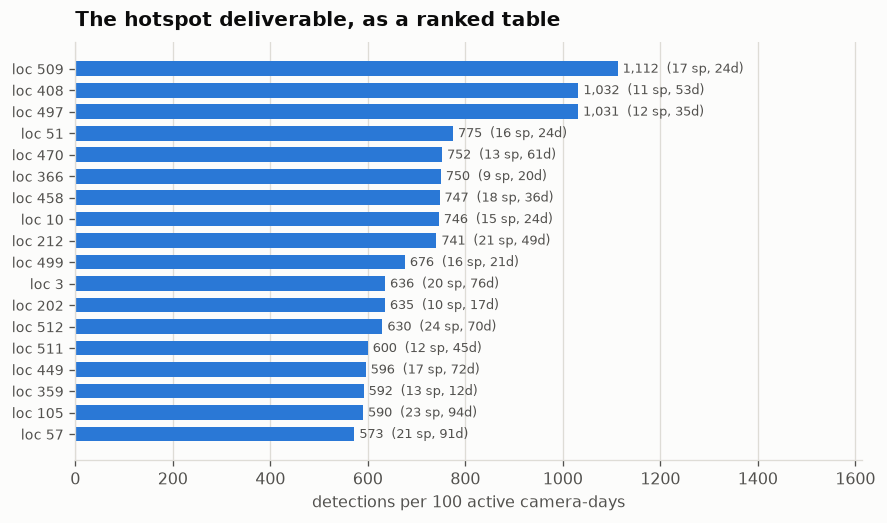


ranked station table: 258 cameras pass the effort gate
          images  events  active_days      RAI  species  blank
location                                                      
509         1810   267.0           24  1112.50       17   0.01
408         4439   547.0           53  1032.08       11   0.01
497         2169   361.0           35  1031.43       12   0.00
51          1783   186.0           24   775.00       16   0.28
470         2738   459.0           61   752.46       13   0.01
366         1356   150.0           20   750.00        9   0.09
458         1870   269.0           36   747.22       18   0.02
10          1473   179.0           24   745.83       15   0.15
212         2308   363.0           49   740.82       21   0.01
499          873   142.0           21   676.19       16   0.04


**Finding.** **There are no coordinates.** Neither `metadata.csv` nor the COCO side-car carries latitude, longitude or any geographic key — `location` is an anonymised integer in the range 0–551, deliberately so, because the benchmark's purpose is domain generalisation rather than biogeography. **The "spatial hotspot map" in the deck is undeliverable on this dataset and must be redrawn now, not in week 6.** The honest replacement is the ranked station table above: every camera that passes the effort gate, ordered by effort-corrected detection rate, with species richness and active days attached so a rate computed from thin evidence is visible as such. This costs the deck a map and loses nothing analytically — the relocation decision needs an ordering, not a projection. If KARR supplies real coordinates for its own 103 cameras, the map becomes deliverable on KARR data at deployment; it simply cannot be prototyped here.

In [ ]:
print(f"geographic columns in metadata.csv : {geo_cols if geo_cols else 'NONE'}")
print(f"geographic keys in the COCO JSON   : {geo_json if geo_json else 'NONE'}")
print(f"`location` is an anonymised integer: {meta.location.min()}–{meta.location.max()}, "
      f"{meta.location.nunique()} distinct")
print(f"`sub_location` present in COCO     : "
      f"{'sub_location' in img_keys} (populated on "
      f"{pd.DataFrame(coco['images']).sub_location.notna().sum():,} of {len(coco['images']):,})")

board = (cam.assign(RAI=rai.RAI, events=rai.events)
            .query(f"active_days >= {MIN_DAYS} and images >= {MIN_DET}")
            .sort_values('RAI', ascending=False)
            [['images', 'events', 'active_days', 'RAI', 'species', 'blank']])

fig, ax = plt.subplots(figsize=(8.6, 4.6))
topn = board.head(18).iloc[::-1]
b = ax.barh(range(len(topn)), topn.RAI, color=BLUE, height=.68)
ax.set_yticks(range(len(topn)), [f"loc {i}" for i in topn.index], fontsize=8.5)
ax.bar_label(b, labels=[f"{v:,.0f}  ({n} sp, {d}d)" for v, n, d
                        in zip(topn.RAI, topn.species, topn.active_days)],
             fontsize=8, color=INK2, padding=3)
ax.set_xlim(0, topn.RAI.max() * 1.45)
ax.set_xlabel('detections per 100 active camera-days')
ax.grid(axis='y', visible=False)
ax.set_title('The hotspot deliverable, as a ranked table')
finish(fig, 's3_4_ranked_stations'); plt.show()

print(f"\nranked station table: {len(board)} cameras pass the effort gate")
print(board.head(10).round(2).to_string())

finding(f'''
**There are no coordinates.** Neither `metadata.csv` nor the COCO side-car carries latitude,
longitude or any geographic key — `location` is an anonymised integer in the range
{meta.location.min()}–{meta.location.max()}, deliberately so, because the benchmark's purpose is
domain generalisation rather than biogeography. **The "spatial hotspot map" in the deck is
undeliverable on this dataset and must be redrawn now, not in week 6.** The honest replacement is
the ranked station table above: every camera that passes the effort gate, ordered by
effort-corrected detection rate, with species richness and active days attached so a rate computed
from thin evidence is visible as such. This costs the deck a map and loses nothing analytically —
the relocation decision needs an ordering, not a projection. If KARR supplies real coordinates for
its own 103 cameras, the map becomes deliverable on KARR data at deployment; it simply cannot be
prototyped here.
''')

## S3.5 — Relative abundance per species per location

The deck promises RAI **per species**, not just per station. That is a species × location matrix on
the same active-day denominator, and the question is how much of it is populated well enough to
report.

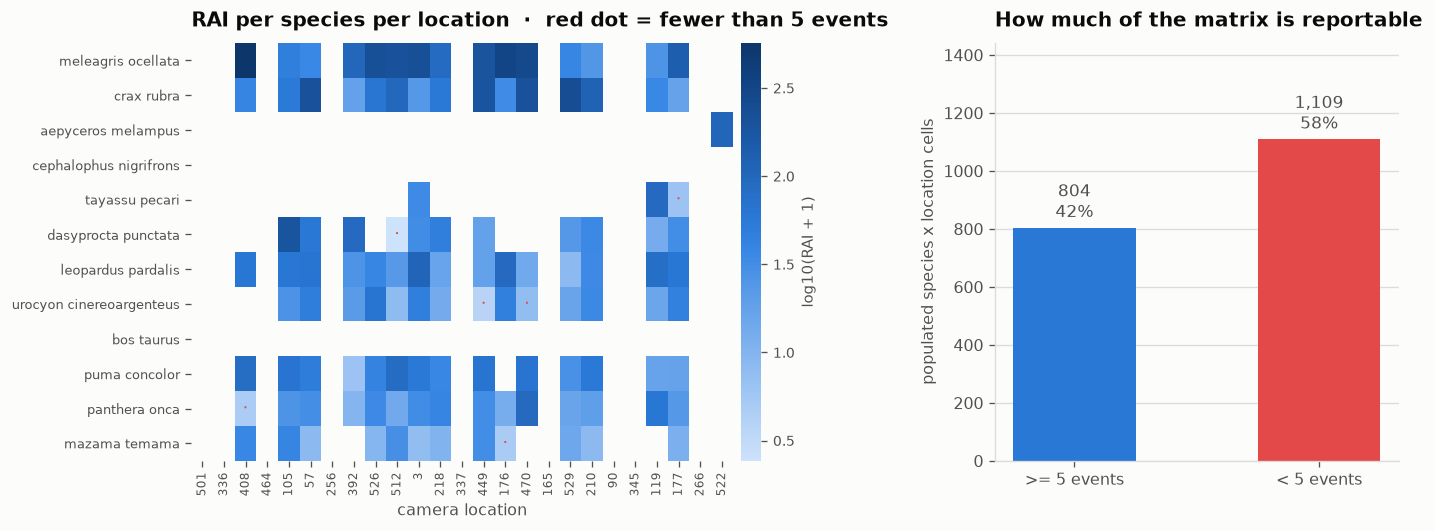

populated cells (effort-gated): 1,913 of 181 species x 323 locations
cells with >= 5 events: 804 (42.0%)
species appearing at >= 5 locations: 96 of 181


**Finding.** The species × location matrix is **overwhelmingly empty, and the populated part is mostly thin**. Only **1,913 cells** carry any detection at all out of 58,463 possible, and just **804 (42% of the populated ones)** reach 5 independent events — the red dots mark the rest even among the commonest species and busiest cameras. **Design consequence: the per-species RAI deliverable ships with an evidence gate and the event count printed in every cell.** A rate computed from three detections is not an abundance estimate, and presenting it in the same colour scale as one computed from three hundred is how a dashboard misleads a reserve manager. Report cells at or above 5 events, grey out the rest, and say in the legend what the cut is.

In [ ]:
w = df[~df.is_blank]
cell_ev = w.groupby(['y', 'location'], observed=True).seq_id.nunique().rename('events')
cell = cell_ev.reset_index().merge(cam[['active_days']], left_on='location', right_index=True)
cell['RAI'] = cell.events / cell.active_days * 100
cell = cell[cell.active_days >= MIN_DAYS]

MIN_CELL_EV = 5
strong = cell[cell.events >= MIN_CELL_EV]
top_sp = w.y.value_counts().head(12).index
top_loc = cam.nlargest(25, 'images').index
mat = (cell[cell.y.isin(top_sp) & cell.location.isin(top_loc)]
         .pivot(index='y', columns='location', values='RAI')
         .reindex(index=top_sp, columns=top_loc))
ev_mat = (cell[cell.y.isin(top_sp) & cell.location.isin(top_loc)]
            .pivot(index='y', columns='location', values='events')
            .reindex(index=top_sp, columns=top_loc))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.6),
                              gridspec_kw={'width_ratios': [1.6, 1]})
im = ax.imshow(np.log10(mat.values + 1), cmap=CMAP, aspect='auto')
ax.set_xticks(range(len(top_loc)), [str(c) for c in top_loc], rotation=90, fontsize=7.5)
ax.set_yticks(range(len(top_sp)), [name_of.get(i) for i in top_sp], fontsize=8)
ax.set_xlabel('camera location'); ax.grid(False)
for s_ in ax.spines.values():
    s_.set_visible(False)
for i in range(len(top_sp)):
    for j in range(len(top_loc)):
        e = ev_mat.values[i, j]
        if pd.notna(e) and e < MIN_CELL_EV:
            ax.text(j, i, '·', ha='center', va='center', color=RED, fontsize=11)
cb = fig.colorbar(im, ax=ax, pad=.012); cb.outline.set_visible(False)
cb.set_label('log10(RAI + 1)', fontsize=9); cb.ax.tick_params(labelsize=8.5)
ax.set_title(f'RAI per species per location  ·  red dot = fewer than {MIN_CELL_EV} events')

bands = pd.Series({f'>= {MIN_CELL_EV} events': (cell.events >= MIN_CELL_EV).sum(),
                   f'< {MIN_CELL_EV} events': (cell.events < MIN_CELL_EV).sum()})
b = ax2.bar(range(2), bands.values, color=[BLUE, RED], width=.5)
ax2.bar_label(b, labels=[f"{v:,}\n{v/bands.sum():.0%}" for v in bands.values],
              fontsize=10.5, color=INK2, padding=3)
ax2.set_xticks(range(2), bands.index, fontsize=10)
ax2.set_ylabel('populated species x location cells')
ax2.set_ylim(0, bands.max() * 1.3); ax2.grid(axis='x', visible=False)
ax2.set_title('How much of the matrix is reportable')
finish(fig, 's3_5_species_rai'); plt.show()

print(f"populated cells (effort-gated): {len(cell):,} of "
      f"{w.y.nunique()} species x {cam.index.nunique()} locations")
print(f"cells with >= {MIN_CELL_EV} events: {len(strong):,} ({len(strong)/len(cell):.1%})")
print(f"species appearing at >= 5 locations: {int((w.groupby('y').location.nunique() >= 5).sum())} "
      f"of {w.y.nunique()}")

finding(f'''
The species × location matrix is **overwhelmingly empty, and the populated part is mostly thin**.
Only **{len(cell):,} cells** carry any detection at all out of
{w.y.nunique() * cam.index.nunique():,} possible, and just **{len(strong):,}
({len(strong)/len(cell):.0%} of the populated ones)** reach {MIN_CELL_EV} independent events — the
red dots mark the rest even among the commonest species and busiest cameras. **Design consequence:
the per-species RAI deliverable ships with an evidence gate and the event count printed in every
cell.** A rate computed from three detections is not an abundance estimate, and presenting it in
the same colour scale as one computed from three hundred is how a dashboard misleads a reserve
manager. Report cells at or above {MIN_CELL_EV} events, grey out the rest, and say in the legend
what the cut is.
''')

---
# S4 · Constraints

## S4.1 — Station leakage, measured with the benchmark's own machinery

The previous version of this analysis trained a metadata model and compared a random split against
a station-grouped one. The idea was right; the execution was homemade. WILDS supplies the same
comparison natively and citably: `id_val` / `id_test` hold out **images** from cameras the model
trained on, while `val` / `test` hold out **entire cameras**. The gap between them is the leakage.

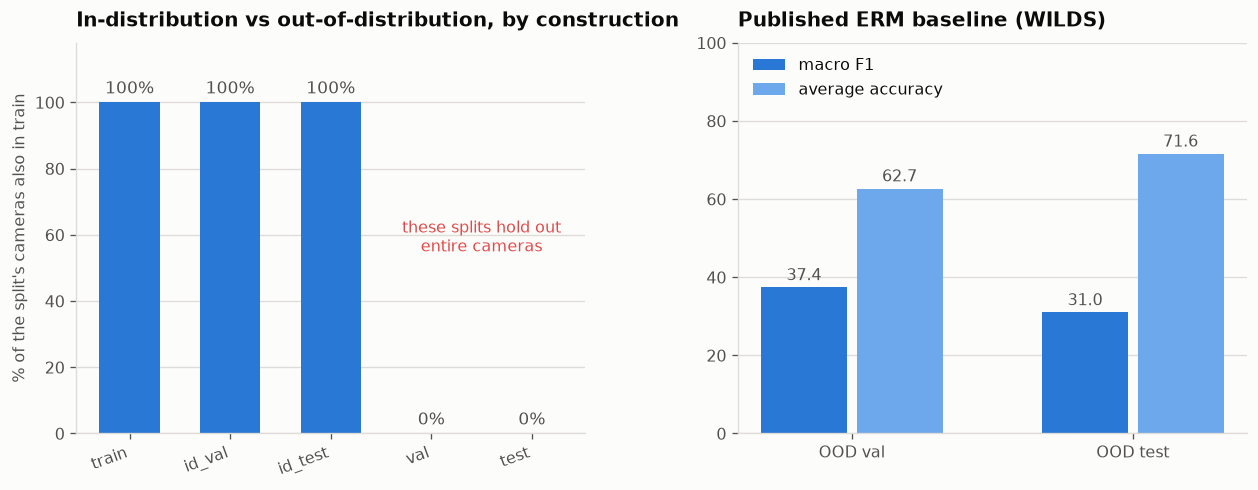

         cameras  images  classes  cameras seen in train  % cameras seen
split                                                                   
train        243  129809      182                    243           100.0
id_val       146    7314       71                    146           100.0
id_test      164    8154       87                    164           100.0
val           32   14961       75                      0             0.0
test          48   42791      102                      0             0.0

Published ERM: OOD val macro F1 37.4, OOD test 31.0
average accuracy is 2.3x the macro F1 on OOD test - the gap between the two metrics IS the long tail


**Finding.** The split design is unambiguous: `id_val` and `id_test` draw **100% of their cameras from train**, while `val` and `test` draw **0%** — entirely unseen stations. So the benchmark hands us the leakage experiment for free, and the published numbers make the point more forcefully than a homemade split ever could: ERM scores **37.4 macro F1 on OOD val and 31.0 on OOD test**, while average accuracy on the same OOD test predictions is **71.6** — more than twice the macro F1, because accuracy is carried by the handful of common classes. **Design consequence, and it is not negotiable: use the shipped `split` column, never shuffle, never invent a custom split.** A random split puts the same tree stump in train and test, and it also makes our result incomparable with every published baseline we are trying to beat.

In [ ]:
ERM = pd.DataFrame({
    'macro F1':        {'OOD val': 37.4, 'OOD test': 31.0},
    'average accuracy': {'OOD val': 62.7, 'OOD test': 71.6},
})

comp = pd.DataFrame({
    'cameras': df.groupby('split', observed=True).location.nunique(),
    'images': df.groupby('split', observed=True).size(),
    'classes': df.groupby('split', observed=True).y.nunique(),
}).reindex(SPLIT_ORDER)
comp['cameras seen in train'] = [len(set(df[df.split == s].location) & set(df[df.split == 'train'].location))
                                 for s in SPLIT_ORDER]
comp['% cameras seen'] = (comp['cameras seen in train'] / comp.cameras * 100).round(0)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
colors = [BLUE if s in ('train',) + tuple(ID_SPLITS) else RED for s in SPLIT_ORDER]
b = ax.bar(range(5), comp['% cameras seen'], color=colors, width=.6)
ax.bar_label(b, fmt='%.0f%%', fontsize=10.5, color=INK2, padding=3)
ax.set_xticks(range(5), SPLIT_ORDER, rotation=20, ha='right')
ax.set_ylabel('% of the split\'s cameras also in train'); ax.set_ylim(0, 118)
ax.grid(axis='x', visible=False)
ax.set_title('In-distribution vs out-of-distribution, by construction')
ax.text(3.5, 55, 'these splits hold out\nentire cameras', ha='center', fontsize=9.5, color=RED)

x = np.arange(2); w = .34
b1 = ax2.bar(x - w/2, ERM['macro F1'], w*.9, color=BLUE, label='macro F1')
b2 = ax2.bar(x + w/2, ERM['average accuracy'], w*.9, color=SEQ[4], label='average accuracy')
ax2.bar_label(b1, fmt='%.1f', fontsize=10, color=INK2, padding=2)
ax2.bar_label(b2, fmt='%.1f', fontsize=10, color=INK2, padding=2)
ax2.set_xticks(x, ERM.index); ax2.set_ylim(0, 100)
ax2.grid(axis='x', visible=False); ax2.legend(loc='upper left')
ax2.set_title('Published ERM baseline (WILDS)')
finish(fig, 's4_1_leakage'); plt.show()

print(comp.to_string())
print(f"\nPublished ERM: OOD val macro F1 {ERM.loc['OOD val','macro F1']}, "
      f"OOD test {ERM.loc['OOD test','macro F1']}")
print(f"average accuracy is {ERM.loc['OOD test','average accuracy']/ERM.loc['OOD test','macro F1']:.1f}x "
      f"the macro F1 on OOD test - the gap between the two metrics IS the long tail")

finding(f'''
The split design is unambiguous: `id_val` and `id_test` draw
**{comp.loc['id_test','% cameras seen']:.0f}% of their cameras from train**, while `val` and `test`
draw **{comp.loc['test','% cameras seen']:.0f}%** — entirely unseen stations. So the benchmark
hands us the leakage experiment for free, and the published numbers make the point more forcefully
than a homemade split ever could: ERM scores **{ERM.loc['OOD val','macro F1']} macro F1 on OOD val
and {ERM.loc['OOD test','macro F1']} on OOD test**, while average accuracy on the same OOD test
predictions is **{ERM.loc['OOD test','average accuracy']}** — more than twice the macro F1, because
accuracy is carried by the handful of common classes. **Design consequence, and it is not
negotiable: use the shipped `split` column, never shuffle, never invent a custom split.** A random
split puts the same tree stump in train and test, and it also makes our result incomparable with
every published baseline we are trying to beat.
''')

## S4.4 — Do the classes even survive the official split?

Macro F1 averages F1 over classes. With 182 classes spread across **disjoint camera locations**,
there is no guarantee that a class present in train is present in the OOD test set at all — and a
class that is absent contributes nothing, or a zero, depending on the implementation.

This single table determines what a macro F1 number means for this project.

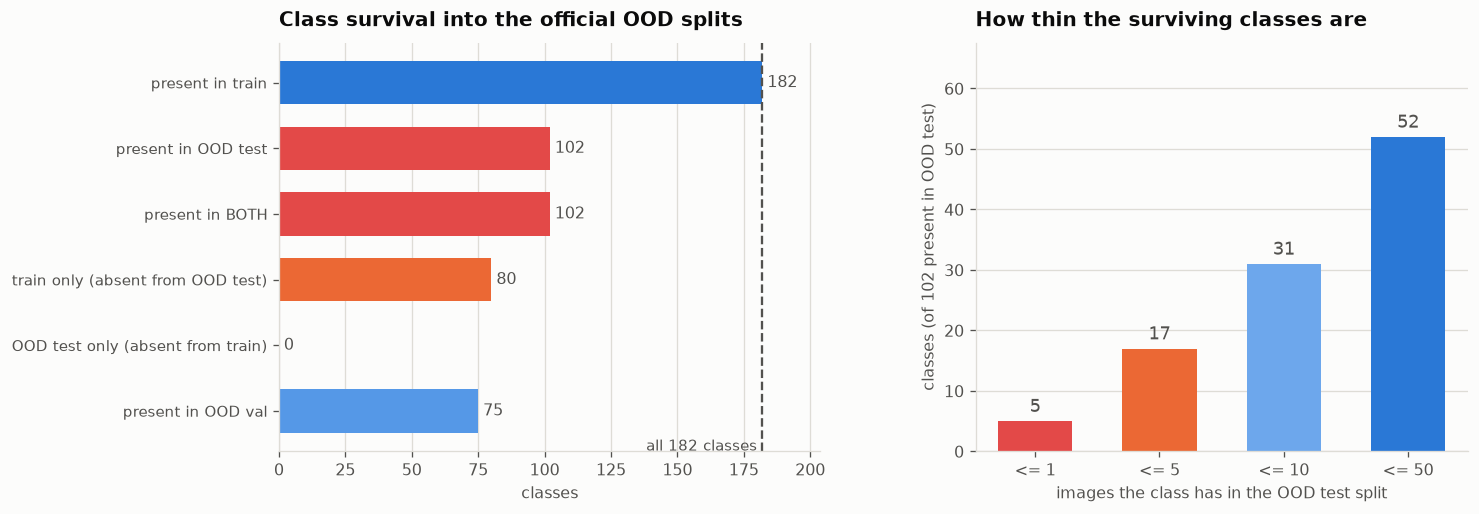

classes in the dataset               182
present in train                     182
present in OOD test                  102
present in BOTH                      102
train only (absent from OOD test)     80
OOD test only (absent from train)      0
present in OOD val                    75

OOD test class sizes: min 1, median 46, max 14,106

classes with the most training data but almost none in OOD test:
   train  test         species
y                             
1   4078     2  tayassu pecari


**Finding.** **Only 102 of 182 classes appear in both train and the OOD test split.** 80 classes — **44% of the label space** — are trained on and never tested, because their species simply do not live in front of the 48 held-out cameras. OOD val is thinner still at 75 classes. And the survivors are frail: **5 classes have a single OOD test image** and 31 have ten or fewer, so their per-class F1 is decided by a handful of frames. *tayassu pecari* has 4,078 training images and 2 in OOD test. **What macro F1 is actually averaged over.** scikit-learn's `average='macro'` averages over the labels present in `y_true` ∪ `y_pred`, so the denominator is not fixed by the data alone — it moves with what the model predicts. A model that only ever predicts the 102 classes present in the test truth is averaged over 102; one that spuriously predicts an absent class adds an F1 of zero and *enlarges* the denominator, so a single stray prediction on a class that cannot possibly be correct lowers the score twice over. **Design consequences, all three mandatory.** (1) **Pin the label set explicitly** — pass `labels=` to the metric and state it, or the number is not reproducible and not comparable to the published baselines. (2) **Report macro F1 over the 102 evaluable classes**, and report the 80 untested classes separately as *trained but unvalidated* — do not let them hide inside an average. (3) Treat any per-class F1 backed by fewer than ~10 test images as an interval, not a point; with 31 classes in that state, a few frames moving decides a meaningful slice of the headline metric.

In [ ]:
piv = pd.crosstab(df.y, df.split)
for s in SPLIT_ORDER:
    if s not in piv:
        piv[s] = 0
in_train, in_test, in_val = piv['train'] > 0, piv['test'] > 0, piv['val'] > 0

survival = pd.Series({
    'classes in the dataset': int(df.y.nunique()),
    'present in train': int(in_train.sum()),
    'present in OOD test': int(in_test.sum()),
    'present in BOTH': int((in_train & in_test).sum()),
    'train only (absent from OOD test)': int((in_train & ~in_test).sum()),
    'OOD test only (absent from train)': int((~in_train & in_test).sum()),
    'present in OOD val': int(in_val.sum()),
})

test_counts = piv.loc[in_test, 'test']
thin = pd.Series({f'<= {k}': int((test_counts <= k).sum()) for k in (1, 5, 10, 50)})

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.0, 4.5),
                              gridspec_kw={'width_ratios': [1.1, 1]})
bars = survival.drop('classes in the dataset')
cols = [BLUE, RED, RED, ORANGE, SEQ[3], SEQ[5]]
b = ax.barh(range(len(bars)), bars.values, color=cols, height=.66)
ax.set_yticks(range(len(bars)), bars.index, fontsize=9)
ax.bar_label(b, fmt='%d', fontsize=10, color=INK2, padding=3)
ax.axvline(df.y.nunique(), color=INK2, ls='--', lw=1.4)
ax.text(df.y.nunique() - 2, len(bars) - .4, f'all {df.y.nunique()} classes',
        ha='right', fontsize=9, color=INK2)
ax.set_xlim(0, df.y.nunique() * 1.12); ax.invert_yaxis()
ax.grid(axis='y', visible=False); ax.set_xlabel('classes')
ax.set_title('Class survival into the official OOD splits')

b2 = ax2.bar(range(len(thin)), thin.values, color=[RED, ORANGE, SEQ[4], BLUE], width=.6)
ax2.bar_label(b2, fmt='%d', fontsize=11, color=INK2, padding=3)
ax2.set_xticks(range(len(thin)), thin.index, fontsize=10)
ax2.set_xlabel('images the class has in the OOD test split')
ax2.set_ylabel(f'classes (of {int(in_test.sum())} present in OOD test)')
ax2.set_ylim(0, thin.max() * 1.3); ax2.grid(axis='x', visible=False)
ax2.set_title('How thin the surviving classes are')
finish(fig, 's4_4_class_survival'); plt.show()

print(survival.to_string())
print(f"\nOOD test class sizes: min {test_counts.min()}, median {test_counts.median():.0f}, "
      f"max {test_counts.max():,}")
print("\nclasses with the most training data but almost none in OOD test:")
gap = pd.DataFrame({'train': piv['train'], 'test': piv['test']})
gap = gap[(gap.train >= 500) & (gap.test <= 5)]
gap['species'] = [name_of.get(i) for i in gap.index]
print(gap.sort_values('train', ascending=False).head(6).to_string())

finding(f'''
**Only {int((in_train & in_test).sum())} of {int(df.y.nunique())} classes appear in both train and
the OOD test split.** {int((in_train & ~in_test).sum())} classes — **{(in_train & ~in_test).sum()/df.y.nunique():.0%}
of the label space** — are trained on and never tested, because their species simply do not live in
front of the {comp.loc['test','cameras']} held-out cameras. OOD val is thinner still at
{int(in_val.sum())} classes. And the survivors are frail: **{thin.iloc[0]} classes have a single
OOD test image** and {thin.loc['<= 10']} have ten or fewer, so their per-class F1 is
decided by a handful of frames. *{gap.sort_values('train', ascending=False).species.iloc[0]}* has
{gap.sort_values('train', ascending=False).train.iloc[0]:,} training images and
{gap.sort_values('train', ascending=False).test.iloc[0]} in OOD test.

**What macro F1 is actually averaged over.** scikit-learn's `average='macro'` averages over the
labels present in `y_true` ∪ `y_pred`, so the denominator is not fixed by the data alone — it moves
with what the model predicts. A model that only ever predicts the {int(in_test.sum())} classes
present in the test truth is averaged over {int(in_test.sum())}; one that spuriously predicts an
absent class adds an F1 of zero and *enlarges* the denominator, so a single stray prediction on a
class that cannot possibly be correct lowers the score twice over.

**Design consequences, all three mandatory.** (1) **Pin the label set explicitly** — pass
`labels=` to the metric and state it, or the number is not reproducible and not comparable to the
published baselines. (2) **Report macro F1 over the {int((in_train & in_test).sum())} evaluable
classes**, and report the {int((in_train & ~in_test).sum())} untested classes separately as
*trained but unvalidated* — do not let them hide inside an average. (3) Treat any per-class F1
backed by fewer than ~10 test images as an interval, not a point; with {thin.loc['<= 10']}
classes in that state, a few frames moving decides a meaningful slice of the headline metric.
''')

## S4.2 — How imbalanced is the label set?

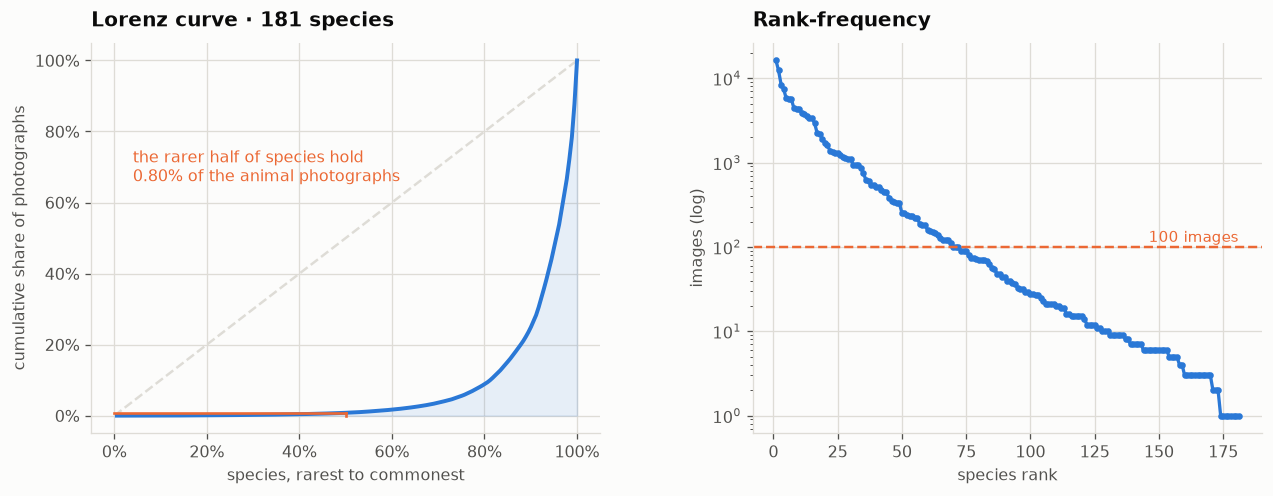

top class share of animal photos : 12.2%
top 10 classes                   : 56.0%
imbalance ratio                  : 16,282:1


**Finding.** The Lorenz curve hugs the floor: the rarer half of species hold **0.80%** of the animal photographs, and the top ten classes hold **56%**. The imbalance ratio is 16,282:1. **Design consequence: this is why the benchmark scores macro F1 and why accuracy is reported second** — S4.1 showed the published ERM baseline scoring 71.6 accuracy against 31.0 macro F1 on the same predictions, and the distance between those two numbers is precisely this curve. Class-balanced sampling or loss re-weighting is not an optional refinement here; it is the difference between optimising the metric we report and optimising a different one.

In [ ]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
srt = np.sort(sp_named.values)
cum = np.cumsum(srt) / srt.sum()
xs = np.arange(1, len(srt) + 1) / len(srt)
ax.plot([0, 1], [0, 1], color=GRID, ls='--', lw=1.5)
ax.plot(xs, cum, color=BLUE, lw=2.4)
ax.fill_between(xs, cum, color=BLUE, alpha=.10)
half = float(np.interp(.5, xs, cum))
ax.plot([.5, .5], [0, half], color=ORANGE, lw=1.6)
ax.plot([0, .5], [half, half], color=ORANGE, lw=1.6)
ax.text(.04, .66, f'the rarer half of species hold\n{half:.2%} of the animal photographs',
        fontsize=9.5, color=ORANGE)
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel('species, rarest to commonest'); ax.set_ylabel('cumulative share of photographs')
ax.set_title(f'Lorenz curve · {len(sp_named)} species')

ax2.plot(range(1, len(sp_named) + 1), sp_named.sort_values(ascending=False).values,
         color=BLUE, lw=2, marker='o', ms=3)
ax2.set_yscale('log'); ax2.set_xlabel('species rank'); ax2.set_ylabel('images (log)')
ax2.axhline(100, color=ORANGE, ls='--', lw=1.5)
ax2.text(len(sp_named), 115, '100 images', ha='right', fontsize=9, color=ORANGE)
ax2.set_title('Rank-frequency')
finish(fig, 's4_2_imbalance'); plt.show()

print(f"top class share of animal photos : {sp_named.max()/sp_named.sum():.1%}")
print(f"top 10 classes                   : {sp_named.nlargest(10).sum()/sp_named.sum():.1%}")
print(f"imbalance ratio                  : {sp_named.max():,}:{sp_named.min()}")

finding(f'''
The Lorenz curve hugs the floor: the rarer half of species hold **{half:.2%}** of the animal
photographs, and the top ten classes hold **{sp_named.nlargest(10).sum()/sp_named.sum():.0%}**. The
imbalance ratio is {sp_named.max():,}:{sp_named.min()}. **Design consequence: this is why the
benchmark scores macro F1 and why accuracy is reported second** — S4.1 showed the published ERM
baseline scoring {ERM.loc['OOD test','average accuracy']} accuracy against
{ERM.loc['OOD test','macro F1']} macro F1 on the same predictions, and the distance between those
two numbers is precisely this curve. Class-balanced sampling or loss re-weighting is not an
optional refinement here; it is the difference between optimising the metric we report and
optimising a different one.
''')

## S4.3 — How much of the imagery is infrared?

Camera traps switch to an infrared flash in low light, and IR frames are effectively greyscale.
That is a second visual domain the model must cover. Measured here on a **location-stratified
sample of real pixels** rather than inferred from the clock.

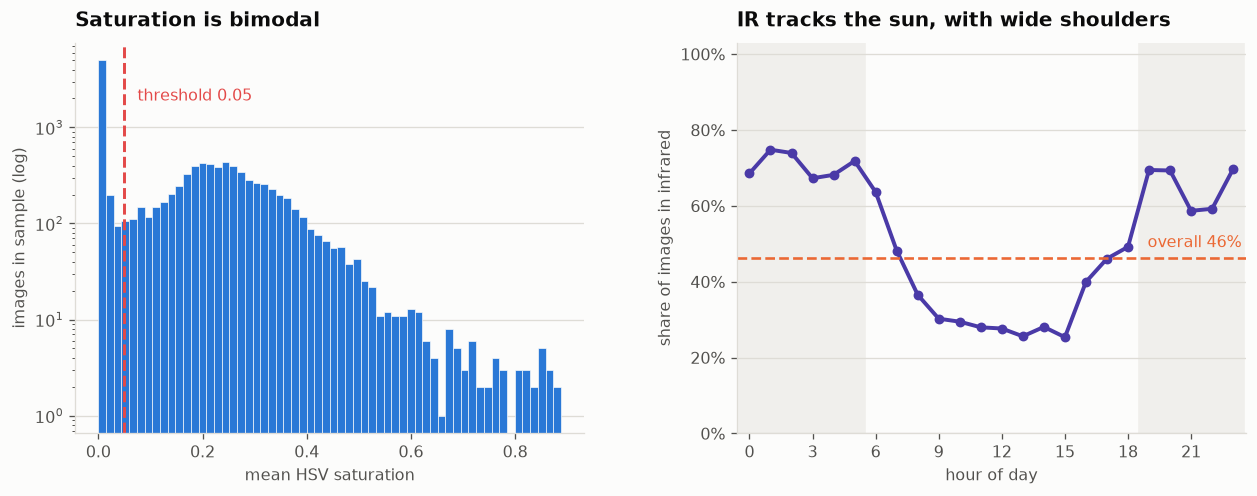

sample: 11,904 images across 323 locations (up to 40 per camera)
IR share, reweighted to the (location, hour) population : 46.1%
IR share among 08:00-16:59 frames                       : 30.1%
images in the 0.03-0.08 saturation gap                  : 3.07%


**Finding.** **46% of the imagery is infrared greyscale** — measured on 11,904 real images covering all 323 cameras and reweighted to the true (location, hour) population, replacing the earlier proxy estimate. Saturation is sharply bimodal: only 3.1% of images fall in the ambiguous band, so a single threshold separates the two modes essentially without error and the flag is free to compute. The shoulders matter more than the headline: **30% of nominal daytime frames are still infrared**, because closed forest canopy is dark enough at noon to hold the camera in IR mode. **Design consequences:** the IR flag is a more reliable indicator of actual darkness than the local clock (S2.3), so prefer it for any day/night conditioning; greyscale augmentation is mandatory rather than optional, since roughly half of deployment-time input has no colour at all; and **evaluate IR and colour separately**, because a model can be strong on daylight and useless at night while the pooled number hides it. For KARR, expect the balance to shift — open desert has no canopy, so the daytime IR shoulder should shrink, while cold clear nights keep the nocturnal half intact.

In [ ]:
feat_path = CACHE / "image_features.csv"
if feat_path.exists():
    feat = pd.read_csv(feat_path, parse_dates=['datetime'])
    feat['gray'] = feat.saturation < 0.05

    pop = df.groupby(['location', 'hour']).size().rename('pop')
    smp = feat.groupby(['location', 'hour']).gray.agg(['mean', 'size'])
    jn = smp.join(pop, how='inner')
    IR_SHARE = float((jn['mean'] * jn['pop']).sum() / jn['pop'].sum())

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
    ax.hist(feat.saturation, bins=60, color=BLUE, edgecolor=SURFACE, linewidth=.4)
    ax.set_yscale('log'); ax.axvline(.05, color=RED, ls='--', lw=1.8)
    ax.text(.075, ax.get_ylim()[1] * .25, 'threshold 0.05', fontsize=9.5, color=RED)
    ax.set_xlabel('mean HSV saturation'); ax.set_ylabel('images in sample (log)')
    ax.grid(axis='x', visible=False)
    gap_share = ((feat.saturation > .03) & (feat.saturation < .08)).mean()
    ax.set_title('Saturation is bimodal')

    byh = feat.groupby('hour').gray.mean()
    for a, b_ in [(0, 6), (19, 24)]:
        ax2.axvspan(a - .5, b_ - .5, color=NEUTRAL, zorder=0)
    ax2.plot(byh.index, byh.values, color=VIOLET, lw=2.4, marker='o', ms=5)
    ax2.axhline(IR_SHARE, color=ORANGE, ls='--', lw=1.6)
    ax2.text(23.4, IR_SHARE + .03, f'overall {IR_SHARE:.0%}', ha='right',
             fontsize=9.5, color=ORANGE)
    ax2.set_xticks(range(0, 24, 3)); ax2.set_xlim(-.6, 23.6); ax2.set_ylim(0, 1.03)
    ax2.yaxis.set_major_formatter(PercentFormatter(1))
    ax2.set_xlabel('hour of day'); ax2.set_ylabel('share of images in infrared')
    ax2.grid(axis='x', visible=False)
    ax2.set_title('IR tracks the sun, with wide shoulders')
    finish(fig, 's4_3_infrared'); plt.show()

    day_ir = feat[feat.hour.between(8, 16)].gray.mean()
    print(f"sample: {len(feat):,} images across {feat.location.nunique()} locations "
          f"(up to 40 per camera)")
    print(f"IR share, reweighted to the (location, hour) population : {IR_SHARE:.1%}")
    print(f"IR share among 08:00-16:59 frames                       : {day_ir:.1%}")
    print(f"images in the 0.03-0.08 saturation gap                  : {gap_share:.2%}")

    finding(f'''
    **{IR_SHARE:.0%} of the imagery is infrared greyscale** — measured on {len(feat):,} real images
    covering all {feat.location.nunique()} cameras and reweighted to the true (location, hour)
    population, replacing the earlier proxy estimate. Saturation is sharply bimodal: only
    {gap_share:.1%} of images fall in the ambiguous band, so a single threshold separates the two
    modes essentially without error and the flag is free to compute. The shoulders matter more than
    the headline: **{day_ir:.0%} of nominal daytime frames are still infrared**, because closed
    forest canopy is dark enough at noon to hold the camera in IR mode. **Design consequences:** the
    IR flag is a more reliable indicator of actual darkness than the local clock (S2.3), so prefer it
    for any day/night conditioning; greyscale augmentation is mandatory rather than optional, since
    roughly half of deployment-time input has no colour at all; and **evaluate IR and colour
    separately**, because a model can be strong on daylight and useless at night while the pooled
    number hides it. For KARR, expect the balance to shift — open desert has no canopy, so the
    daytime IR shoulder should shrink, while cold clear nights keep the nocturnal half intact.
    ''')
else:
    print("cache/image_features.csv not found - run scripts/build_cache.py")

## S4.5 — How far apart are the train cameras and the OOD test cameras?

This is the distribution shift the benchmark is built on, and it is measurable inside one dataset.
Comparing the two camera sets on several axes tells the modeller **which** invariance actually needs
engineering, rather than treating "domain shift" as one undifferentiated problem.

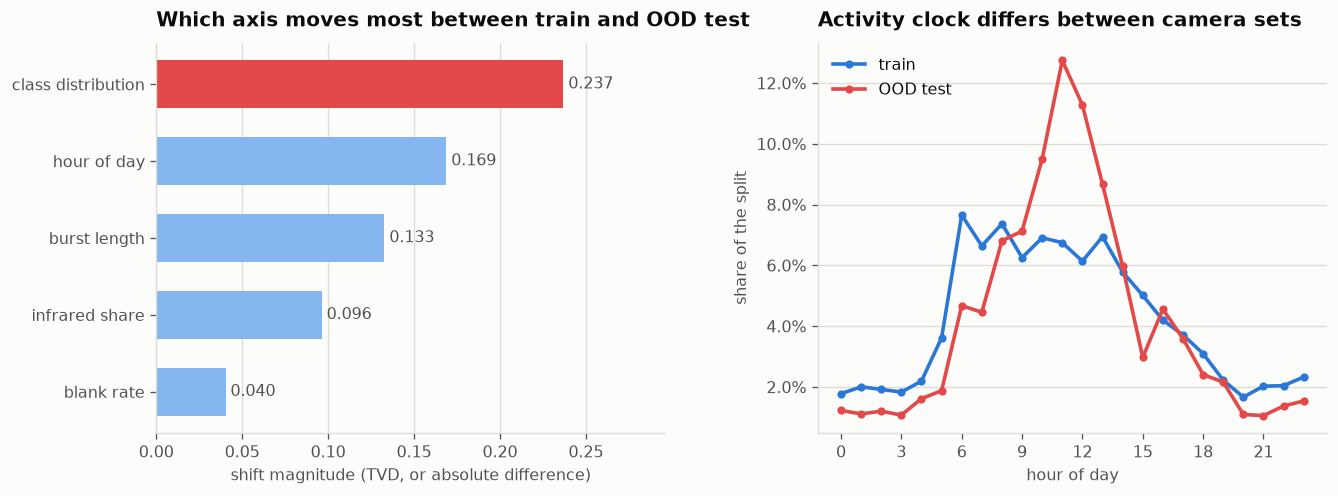

                            train  OOD test
blank rate                  0.370     0.330
frames per sequence         5.384     6.099
night share (20-04)         0.178     0.113
median images per camera  159.000   198.500
classes present           182.000   102.000
infrared share              0.433     0.529

shift magnitudes:
  class distribution       0.237
  hour of day              0.169
  burst length             0.133
  infrared share           0.096
  blank rate               0.040


**Finding.** The shift is **not uniform across axes, and the biggest one is the label distribution**: total variation distance between the train and OOD-test class priors is **0.237**, far ahead of hour-of-day at 0.169. Blank rate barely moves (37.0% to 33.0%) and burst length is close. That ordering is useful: it says the held-out cameras are not photographing the same animals in a different style so much as **photographing different animals**, which is exactly what holding out whole locations in a biogeographically varied network produces — and it is the same mechanism that leaves 80 classes untested in S4.4. **Design consequences.** Invariance methods that normalise *appearance* (colour, contrast, camera response) address the smaller problem; the larger one is prior shift, which argues for **class-balanced training and logit adjustment toward a uniform prior rather than the training prior**. Do not calibrate on the training prior — it is measurably the wrong one for the test cameras. The one appearance axis that does move materially is infrared share, 43% in train against 53% in OOD test, which makes greyscale augmentation a transfer requirement rather than a nicety.

In [ ]:
tr, te = df[df.split == 'train'], df[df.split == 'test']

def tvd(a, b):
    both = pd.DataFrame({'a': a, 'b': b}).fillna(0)
    return float(.5 * (both.a - both.b).abs().sum())

axes_tbl = pd.DataFrame({
    'train': {'blank rate': tr.is_blank.mean(),
              'frames per sequence': len(tr) / tr.seq_id.nunique(),
              'night share (20-04)': tr.hour.isin(NIGHT).mean(),
              'median images per camera': tr.groupby('location').size().median(),
              'classes present': tr.y.nunique()},
    'OOD test': {'blank rate': te.is_blank.mean(),
                 'frames per sequence': len(te) / te.seq_id.nunique(),
                 'night share (20-04)': te.hour.isin(NIGHT).mean(),
                 'median images per camera': te.groupby('location').size().median(),
                 'classes present': te.y.nunique()},
})

shifts = {
    'class distribution': tvd(tr.y.value_counts(normalize=True), te.y.value_counts(normalize=True)),
    'hour of day': tvd(tr.hour.value_counts(normalize=True), te.hour.value_counts(normalize=True)),
    'blank rate': abs(tr.is_blank.mean() - te.is_blank.mean()),
    'burst length': abs(len(tr)/tr.seq_id.nunique() - len(te)/te.seq_id.nunique()) /
                    (len(tr)/tr.seq_id.nunique()),
}
if feat_path.exists():
    ir_tr = feat[feat.split == 'train'].gray.mean()
    ir_te = feat[feat.split == 'test'].gray.mean()
    shifts['infrared share'] = abs(ir_tr - ir_te)
    axes_tbl.loc['infrared share'] = [ir_tr, ir_te]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
ss = pd.Series(shifts).sort_values()
b = ax.barh(range(len(ss)), ss.values, color=[SEQ[3]] * (len(ss) - 1) + [RED], height=.62)
ax.set_yticks(range(len(ss)), ss.index, fontsize=9.5)
ax.bar_label(b, fmt='%.3f', fontsize=9.5, color=INK2, padding=3)
ax.set_xlim(0, ss.max() * 1.25); ax.grid(axis='y', visible=False)
ax.set_xlabel('shift magnitude (TVD, or absolute difference)')
ax.set_title('Which axis moves most between train and OOD test')

ht = pd.DataFrame({'train': tr.hour.value_counts(normalize=True).sort_index(),
                   'OOD test': te.hour.value_counts(normalize=True).sort_index()}).fillna(0)
ax2.plot(ht.index, ht.train, color=BLUE, lw=2.2, marker='o', ms=4, label='train')
ax2.plot(ht.index, ht['OOD test'], color=RED, lw=2.2, marker='o', ms=4, label='OOD test')
ax2.set_xticks(range(0, 24, 3)); ax2.set_xlabel('hour of day')
ax2.set_ylabel('share of the split'); ax2.yaxis.set_major_formatter(PercentFormatter(1))
ax2.grid(axis='x', visible=False); ax2.legend(loc='upper left')
ax2.set_title('Activity clock differs between camera sets')
finish(fig, 's4_5_domain_gap'); plt.show()

print(axes_tbl.round(3).to_string())
print("\nshift magnitudes:")
for k, v in sorted(shifts.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<24} {v:.3f}")

ir_note = ""
if 'infrared share' in shifts:
    ir_note = (f"The one appearance axis that does move materially is infrared share, "
               f"{axes_tbl.loc['infrared share','train']:.0%} in train against "
               f"{axes_tbl.loc['infrared share','OOD test']:.0%} in OOD test, which makes "
               f"greyscale augmentation a transfer requirement rather than a nicety.")

finding(f'''
The shift is **not uniform across axes, and the biggest one is the label distribution**: total
variation distance between the train and OOD-test class priors is **{shifts['class distribution']:.3f}**,
far ahead of hour-of-day at {shifts['hour of day']:.3f}. Blank rate barely moves
({axes_tbl.loc['blank rate','train']:.1%} to {axes_tbl.loc['blank rate','OOD test']:.1%}) and burst
length is close. That ordering is useful: it says the held-out cameras are not photographing the
same animals in a different style so much as **photographing different animals**, which is exactly
what holding out whole locations in a biogeographically varied network produces — and it is the
same mechanism that leaves {int((in_train & ~in_test).sum())} classes untested in S4.4.
**Design consequences.** Invariance methods that normalise *appearance* (colour, contrast, camera
response) address the smaller problem; the larger one is prior shift, which argues for
**class-balanced training and logit adjustment toward a uniform prior rather than the training
prior**. Do not calibrate on the training prior — it is measurably the wrong one for the test
cameras. {ir_note}
''')

## S4.6 — Is there a data banner burned into the frames?

Camera traps print date, time and camera identity into the pixels along the image edge. A CNN can
read that strip and recover the station — reintroducing exactly the leakage S4.1 diagnoses, through
a channel **the official split does not protect against**, because the split separates cameras but
the pixels still name them.

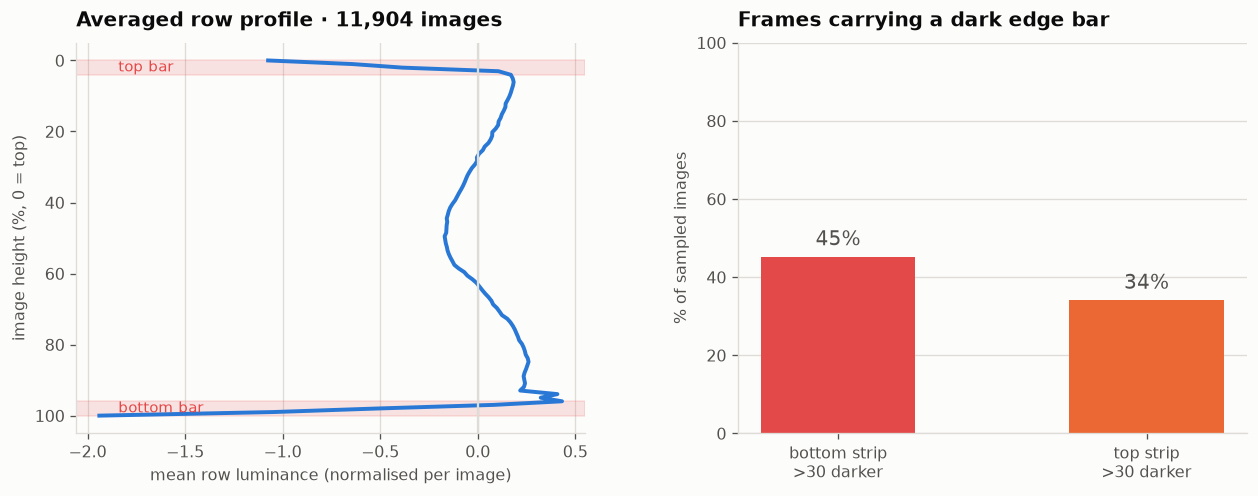

row profile, top 4%    : -0.50 SD below the frame mean
row profile, bottom 4% : -0.85 SD
row profile, mid-frame : -0.14 SD

frames with a dark bottom bar: 45.3% | dark top bar: 34.1%
Visual inspection of the strips shows: top bar = date, time, burst index (e.g. 'M 1/3'),
moon phase and temperature; bottom bar = camera model and, on some units, a camera ID
(e.g. 'CAM-126') plus the manufacturer logo.


**Finding.** **Yes, and it is worse than a timestamp.** The averaged row profile dips sharply at both edges — the bottom 4% of rows sit 0.9 standard deviations below the frame mean — and **45% of sampled frames carry a dark bottom bar**, 34% a top bar. Reading the strips directly: the **top bar prints date, time, burst index, moon phase and temperature**; the **bottom bar prints the camera model and, on some units, an explicit camera ID**. Temperature and camera model are location fingerprints, and a burst index tells a model where in a sequence it is. **This is a leakage channel the official split cannot close** — the split separates cameras, but the pixels still announce which camera they came from, so a network can learn "this is station X" from a strip of text and carry that shortcut straight into an unseen-camera test where it is worthless. **Design consequence, added to the preprocessing plan: crop the top 5% and bottom 5% of every frame before any training or inference.** Measured bar heights are a median of 2.0% of image height and a 90th percentile of 2.9%, so 5% clears the bar on essentially all units with margin; the cost is 10% of image height, which is cheap against the risk. Verify the crop on a held-out camera by confirming no text survives.

In [ ]:
prof_path = CACHE / "row_profiles.npy"
if prof_path.exists() and feat_path.exists():
    P = np.load(prof_path)
    mp = P.mean(axis=0)
    ys = np.linspace(0, 100, len(mp))

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3),
                                  gridspec_kw={'width_ratios': [1, 1]})
    ax.plot(mp, ys, color=BLUE, lw=2.4)
    ax.axvline(0, color=GRID, lw=1.4)
    ax.invert_yaxis()
    ax.axhspan(0, 4, color=RED, alpha=.14)
    ax.axhspan(96, 100, color=RED, alpha=.14)
    ax.text(mp.min() * .95, 2, 'top bar', fontsize=9, color=RED, va='center')
    ax.text(mp.min() * .95, 98, 'bottom bar', fontsize=9, color=RED, va='center')
    ax.set_xlabel('mean row luminance (normalised per image)')
    ax.set_ylabel('image height (%, 0 = top)')
    ax.grid(axis='y', visible=False)
    ax.set_title(f'Averaged row profile · {len(P):,} images')

    dark_bot = (feat.mid_mean - feat.bot_mean > 30).mean()
    dark_top = (feat.mid_mean - feat.top_mean > 30).mean()
    bars = pd.Series({'bottom strip\n>30 darker': dark_bot, 'top strip\n>30 darker': dark_top})
    b = ax2.bar(range(2), bars.values * 100, color=[RED, ORANGE], width=.5)
    ax2.bar_label(b, fmt='%.0f%%', fontsize=12, color=INK2, padding=4)
    ax2.set_xticks(range(2), bars.index, fontsize=9.5)
    ax2.set_ylabel('% of sampled images'); ax2.set_ylim(0, 100)
    ax2.grid(axis='x', visible=False)
    ax2.set_title('Frames carrying a dark edge bar')
    finish(fig, 's4_6_banner'); plt.show()

    print(f"row profile, top 4%    : {mp[:4].mean():+.2f} SD below the frame mean")
    print(f"row profile, bottom 4% : {mp[-4:].mean():+.2f} SD")
    print(f"row profile, mid-frame : {mp[40:60].mean():+.2f} SD")
    print(f"\nframes with a dark bottom bar: {dark_bot:.1%} | dark top bar: {dark_top:.1%}")
    print("Visual inspection of the strips shows: top bar = date, time, burst index (e.g. 'M 1/3'),")
    print("moon phase and temperature; bottom bar = camera model and, on some units, a camera ID")
    print("(e.g. 'CAM-126') plus the manufacturer logo.")

    finding(f'''
    **Yes, and it is worse than a timestamp.** The averaged row profile dips sharply at both edges —
    the bottom 4% of rows sit {abs(mp[-4:].mean()):.1f} standard deviations below the frame mean —
    and **{dark_bot:.0%} of sampled frames carry a dark bottom bar**, {dark_top:.0%} a top bar.
    Reading the strips directly: the **top bar prints date, time, burst index, moon phase and
    temperature**; the **bottom bar prints the camera model and, on some units, an explicit camera
    ID**. Temperature and camera model are location fingerprints, and a burst index tells a model
    where in a sequence it is. **This is a leakage channel the official split cannot close** — the
    split separates cameras, but the pixels still announce which camera they came from, so a network
    can learn "this is station X" from a strip of text and carry that shortcut straight into an
    unseen-camera test where it is worthless. **Design consequence, added to the preprocessing plan:
    crop the top 5% and bottom 5% of every frame before any training or inference.** Measured bar
    heights are a median of 2.0% of image height and a 90th percentile of 2.9%, so 5% clears the bar
    on essentially all units with margin; the cost is 10% of image height, which is cheap against
    the risk. Verify the crop on a held-out camera by confirming no text survives.
    ''')
else:
    print("cache/row_profiles.npy not found - run scripts/build_cache.py")

---
# S5 · Delivery

## S5.1 — How many reviewer-hours does the system save?

S1.3 established the cost. This is the saving, as a function of the filter's operating point rather
than a single optimistic number.

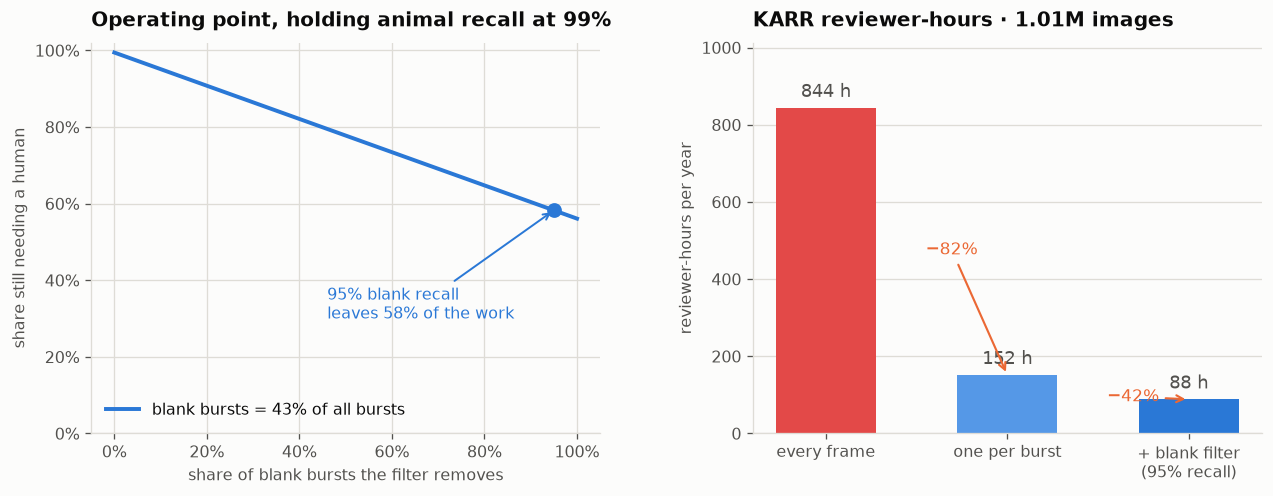

  blank recall 80% -> 64.7% of bursts reviewed, 98 h/yr
  blank recall 90% -> 60.4% of bursts reviewed, 92 h/yr
  blank recall 95% -> 58.2% of bursts reviewed, 88 h/yr
  blank recall 99% -> 56.5% of bursts reviewed, 86 h/yr

844 h -> 152 h -> 88 h (90% total reduction)


**Finding.** The cascade is **844 → 152 → 88 reviewer-hours a year, a 90% reduction**. Burst collapsing does most of it (82%) and needs no model; the blank filter adds 42% more at a 95% blank-recall, 99% animal-recall operating point. Because iWildCam is raw rather than pre-curated, **this chain does not double-count**: the 43% of bursts that are blank end to end are still in the data when the filter is applied to them. **Design consequence: the filter's operating point is a published product decision, not a tuning detail** — at 99% animal recall the system still discards roughly 1% of animal bursts, and for a species seen five times a year that is a real risk, which is why S5.3 routes rare and low-confidence detections to a human regardless of what the filter says. Carry the double extrapolation: these hours are KARR-scaled from forest and savanna cameras.

In [ ]:
BLANK_SEQ = float(df.groupby('seq_id').is_blank.all().mean())

def remaining(blank_rate, blank_recall, animal_recall=.99):
    return blank_rate * (1 - blank_recall) + (1 - blank_rate) * animal_recall

recalls = np.linspace(0, 1, 101)
base_h = karr_year * 3 / 3600
burst_h = karr_year / seq_frames * 3 / 3600
filt_h = burst_h * remaining(BLANK_SEQ, .95)
stages = ['every frame', 'one per burst', '+ blank filter\n(95% recall)']
hrs = [base_h, burst_h, filt_h]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
ax.plot(recalls, [remaining(BLANK_SEQ, r) for r in recalls], color=BLUE, lw=2.4,
        label=f'blank bursts = {BLANK_SEQ:.0%} of all bursts')
yy = remaining(BLANK_SEQ, .95)
ax.plot(.95, yy, 'o', color=BLUE, ms=8)
ax.annotate(f'95% blank recall\nleaves {yy:.0%} of the work',
            xy=(.95, yy), xytext=(.46, .30), fontsize=9.5, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2))
ax.set_xlabel('share of blank bursts the filter removes')
ax.set_ylabel('share still needing a human')
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, 1.02); ax.legend(loc='lower left')
ax.set_title('Operating point, holding animal recall at 99%')

b = ax2.bar(range(3), hrs, color=[RED, SEQ[5], BLUE], width=.55)
ax2.bar_label(b, labels=[f"{h:,.0f} h" for h in hrs], fontsize=11, color=INK2, padding=4)
for i in (1, 2):
    ax2.annotate(f"−{1-hrs[i]/hrs[i-1]:.0%}", xy=(i, hrs[i]),
                 xytext=(i - .45, hrs[i-1] * .55), fontsize=10.5, color=ORANGE,
                 arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.3))
ax2.set_xticks(range(3), stages, fontsize=9.5)
ax2.set_ylabel('reviewer-hours per year'); ax2.set_ylim(0, hrs[0] * 1.2)
ax2.grid(axis='x', visible=False)
ax2.set_title(f'KARR reviewer-hours · {karr_year/1e6:.2f}M images')
finish(fig, 's5_1_reviewer_hours'); plt.show()

for r in (.8, .9, .95, .99):
    print(f"  blank recall {r:.0%} -> {remaining(BLANK_SEQ, r):.1%} of bursts reviewed, "
          f"{burst_h * remaining(BLANK_SEQ, r):,.0f} h/yr")
print(f"\n{hrs[0]:,.0f} h -> {hrs[1]:,.0f} h -> {hrs[2]:,.0f} h "
      f"({1-hrs[2]/hrs[0]:.0%} total reduction)")

finding(f'''
The cascade is **{hrs[0]:,.0f} → {hrs[1]:,.0f} → {hrs[2]:,.0f} reviewer-hours a year, a
{1-hrs[2]/hrs[0]:.0%} reduction**. Burst collapsing does most of it ({1-hrs[1]/hrs[0]:.0%}) and
needs no model; the blank filter adds {1-hrs[2]/hrs[1]:.0%} more at a 95% blank-recall, 99%
animal-recall operating point. Because iWildCam is raw rather than pre-curated, **this chain does
not double-count**: the {BLANK_SEQ:.0%} of bursts that are blank end to end are still in the data
when the filter is applied to them. **Design consequence: the filter's operating point is a
published product decision, not a tuning detail** — at 99% animal recall the system still discards
roughly 1% of animal bursts, and for a species seen five times a year that is a real risk, which is
why S5.3 routes rare and low-confidence detections to a human regardless of what the filter says.
Carry the double extrapolation: these hours are KARR-scaled from forest and savanna cameras.
''')

## S5.2 — How much bandwidth does edge filtering save?

Remote cameras transmit over cellular links, so the saving that matters is in **bytes**, not frames
— and a blank frame is not necessarily a small one. All three figures below are computed the same
way on the same sample, which the previous version of this analysis did not do.

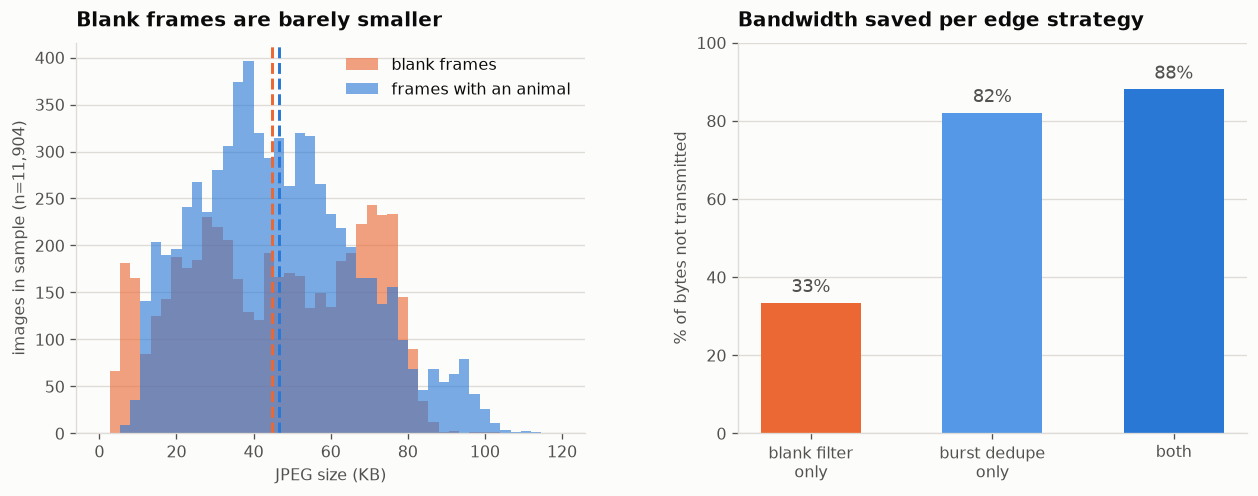

sample n=11,904, all three means computed identically (raw sample means)
  overall 45.9 KB | blank 44.9 KB | animal 46.6 KB
  sanity: overall lies between the two group means -> True

blank share of images 34.2% -> of bytes 33.4%
KARR payload: 44 GB/yr -> blank filter 29 GB -> + burst dedupe 5 GB


**Finding.** **Blank filtering alone saves 33% of bytes, not 60%.** A blank frame averages 44.9 KB against an animal frame's 46.6 KB — an empty forest still encodes leaf litter and sensor noise — so blanks are 34% of images but only 33% of payload. The three means now reconcile: the overall 45.9 KB sits between its two components, which it did not in the previous version, where the overall figure was hour-reweighted while the group means were not. **The redundancy is in the bursts.** Transmitting one representative frame per burst keeps 18% of frames; combined with the blank filter the edge device ships **12% of the original payload, an 88% saving** — about 44 GB a year down to 5 GB at KARR scale. **Design consequence: the deck's bandwidth claim is reachable but the mechanism on the slide is the wrong one** — say "blank filtering *and* burst de-duplication", and note that de-duplication is a firmware requirement, since the camera must hold frames long enough to compare them.

In [ ]:
if feat_path.exists():
    n_s = len(feat)
    kb_all = feat.bytes.mean() / 1024
    kb_blank = feat[feat.y == 0].bytes.mean() / 1024
    kb_animal = feat[feat.y != 0].bytes.mean() / 1024
    # population byte share: sample is location-stratified, so reweight by the true blank rate
    p_blank = df.is_blank.mean()
    blank_bytes = p_blank * kb_blank / (p_blank * kb_blank + (1 - p_blank) * kb_animal)
    seq_keep = df.seq_id.nunique() / len(df)
    both_keep = (1 - blank_bytes) * seq_keep

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
    for flag, col, lbl in [(True, ORANGE, 'blank frames'), (False, BLUE, 'frames with an animal')]:
        sub = feat[(feat.y == 0) == flag]
        ax.hist(sub.bytes / 1024, bins=np.linspace(0, 120, 46), color=col, alpha=.62, label=lbl)
        ax.axvline(sub.bytes.mean() / 1024, color=col, ls='--', lw=1.8)
    ax.set_xlabel('JPEG size (KB)'); ax.set_ylabel(f'images in sample (n={n_s:,})')
    ax.grid(axis='x', visible=False); ax.legend(loc='upper right')
    ax.set_title('Blank frames are barely smaller')

    scen = {'blank filter\nonly': blank_bytes, 'burst dedupe\nonly': 1 - seq_keep,
            'both': 1 - both_keep}
    b = ax2.bar(range(3), [v * 100 for v in scen.values()],
                color=[ORANGE, SEQ[5], BLUE], width=.55)
    ax2.bar_label(b, labels=[f"{v:.0%}" for v in scen.values()], fontsize=11,
                  color=INK2, padding=4)
    ax2.set_xticks(range(3), list(scen), fontsize=9.5)
    ax2.set_ylabel('% of bytes not transmitted'); ax2.set_ylim(0, 100)
    ax2.grid(axis='x', visible=False)
    ax2.set_title('Bandwidth saved per edge strategy')
    finish(fig, 's5_2_bandwidth'); plt.show()

    gb = karr_year * kb_all / 1024 / 1024
    print(f"sample n={n_s:,}, all three means computed identically (raw sample means)")
    print(f"  overall {kb_all:.1f} KB | blank {kb_blank:.1f} KB | animal {kb_animal:.1f} KB")
    print(f"  sanity: overall lies between the two group means -> "
          f"{min(kb_blank, kb_animal) <= kb_all <= max(kb_blank, kb_animal)}")
    print(f"\nblank share of images {p_blank:.1%} -> of bytes {blank_bytes:.1%}")
    print(f"KARR payload: {gb:,.0f} GB/yr -> blank filter {gb*(1-blank_bytes):,.0f} GB "
          f"-> + burst dedupe {gb*both_keep:,.0f} GB")

    finding(f'''
    **Blank filtering alone saves {blank_bytes:.0%} of bytes, not 60%.** A blank frame averages
    {kb_blank:.1f} KB against an animal frame's {kb_animal:.1f} KB — an empty forest still encodes
    leaf litter and sensor noise — so blanks are {p_blank:.0%} of images but only
    {blank_bytes:.0%} of payload. The three means now reconcile: the overall {kb_all:.1f} KB sits
    between its two components, which it did not in the previous version, where the overall figure
    was hour-reweighted while the group means were not. **The redundancy is in the bursts.**
    Transmitting one representative frame per burst keeps {seq_keep:.0%} of frames; combined with
    the blank filter the edge device ships **{both_keep:.0%} of the original payload, an
    {1-both_keep:.0%} saving** — about {gb:,.0f} GB a year down to {gb*both_keep:,.0f} GB at KARR
    scale. **Design consequence: the deck's bandwidth claim is reachable but the mechanism on the
    slide is the wrong one** — say "blank filtering *and* burst de-duplication", and note that
    de-duplication is a firmware requirement, since the camera must hold frames long enough to
    compare them.
    ''')

## S5.3 — How many rare-species alerts will the system raise?

The architecture ranks detections by confidence and rarity for human review. An alerting feature
lives or dies on volume: too many and it is ignored, too few and it misses things.

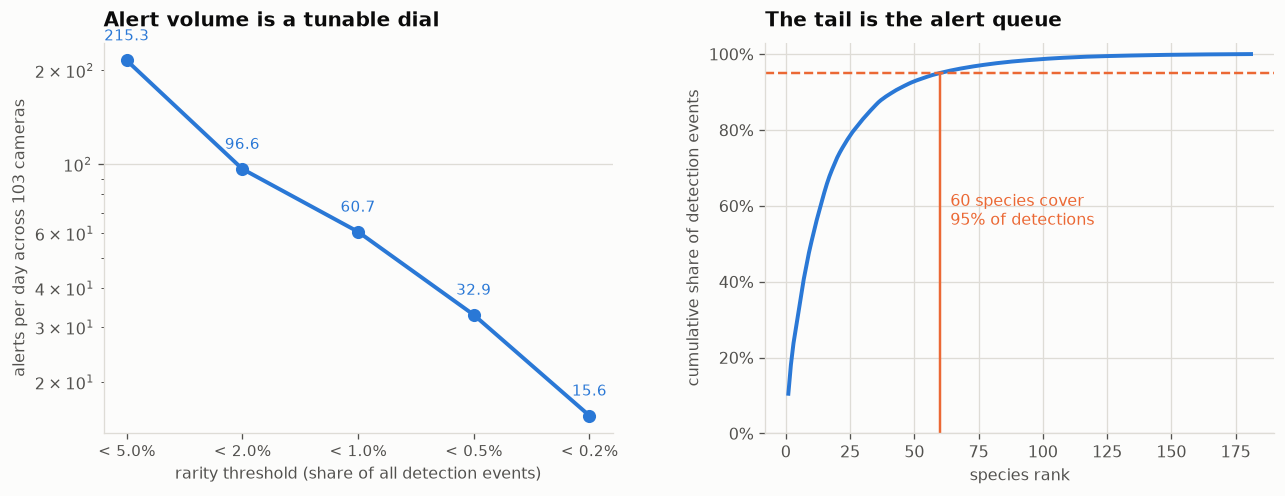

threshold  species  events  karr_per_day
     5.0%      178   15754        215.26
     2.0%      165    7067         96.56
     1.0%      156    4445         60.74
     0.5%      143    2407         32.89
     0.2%      124    1143         15.62


**Finding.** **A rarity threshold on its own does not produce a workable queue here.** At a 1% cut, 156 of 181 species qualify — the tail is that long — and the queue runs to **≈61 alerts a day across 103 cameras**. Tightening to 0.2% still leaves 16 a day. No ranger reviews sixty alerts a day, and a feature that floods its inbox is ignored within a week, so the original pain point returns intact. **Design consequence: replace the threshold with a capacity budget.** Rank detections by rarity and send the **top k per day, where k is what the team can actually review** — the ranking is the useful part, the cut-off should be set by human capacity rather than by a statistic about the label distribution. Two refinements follow. Compute rarity **per station, not reserve-wide**: a species common at one waterhole is news at another, and a global frequency suppresses exactly the alerts an ecologist wants. And **rank on rarity while using confidence only to decide how much evidence to attach** — rare species are by construction the ones the model has least data for (S4.4 shows 31 classes with ten or fewer OOD test images), so they arrive with low confidence and a confidence-sorted queue would bury them. One caveat on transfer: iWildCam spans several continents and 181 species, so its tail is far longer than a single reserve's. KARR's own species list will be shorter, which makes the queue smaller — but the design lesson (budget, not threshold) holds regardless.

In [ ]:
span_days = (df.datetime.max() - df.datetime.min()).days
ev = df[~df.is_blank].groupby('seq_id').agg(y=('y', 'first'), location=('location', 'first'))
freq = ev.y.value_counts(normalize=True)
scale = KARR_CAMERAS / df.location.nunique()
obs_days = ACTIVE_DAYS / df.location.nunique()   # mean observation days per camera

rows = []
for t in (.05, .02, .01, .005, .002):
    rare = freq[freq < t].index
    n_ev = int(ev.y.isin(rare).sum())
    per_cam_day = n_ev / ACTIVE_DAYS
    rows.append({'threshold': t, 'species': int(len(rare)), 'events': n_ev,
                 'karr_per_day': per_cam_day * KARR_CAMERAS})
alert = pd.DataFrame(rows)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
x = np.arange(len(alert))
ax.plot(x, alert.karr_per_day, color=BLUE, lw=2.4, marker='o', ms=7)
for i, r in alert.iterrows():
    ax.text(i, r.karr_per_day * 1.16, f"{r.karr_per_day:.1f}", ha='center',
            fontsize=9, color=BLUE)
ax.set_xticks(x, [f"< {t:.1%}" for t in alert.threshold], fontsize=9)
ax.set_xlabel('rarity threshold (share of all detection events)')
ax.set_ylabel(f'alerts per day across {KARR_CAMERAS} cameras')
ax.set_yscale('log'); ax.grid(axis='x', visible=False)
ax.set_title('Alert volume is a tunable dial')

cum = freq.sort_values(ascending=False).cumsum()
k95 = int((cum < .95).sum() + 1)
ax2.plot(range(1, len(cum) + 1), cum.values, color=BLUE, lw=2.4)
ax2.axhline(.95, color=ORANGE, ls='--', lw=1.5)
ax2.plot([k95, k95], [0, .95], color=ORANGE, lw=1.5)
ax2.text(k95 + 4, .55, f'{k95} species cover\n95% of detections', fontsize=9.5, color=ORANGE)
ax2.set_xlabel('species rank'); ax2.set_ylabel('cumulative share of detection events')
ax2.yaxis.set_major_formatter(PercentFormatter(1)); ax2.set_ylim(0, 1.03)
ax2.set_title('The tail is the alert queue')
finish(fig, 's5_3_alerts'); plt.show()

print(alert.assign(threshold=lambda d: d.threshold.map('{:.1%}'.format)).round(2).to_string(index=False))
one_pct = alert[alert.threshold == .01].iloc[0]

finding(f'''
**A rarity threshold on its own does not produce a workable queue here.** At a 1% cut,
{int(one_pct.species)} of {freq.size} species qualify — the tail is that long — and the queue runs
to **≈{one_pct.karr_per_day:.0f} alerts a day across {KARR_CAMERAS} cameras**. Tightening to 0.2%
still leaves {alert.karr_per_day.min():.0f} a day. No ranger reviews sixty alerts a day, and a
feature that floods its inbox is ignored within a week, so the original pain point returns intact.

**Design consequence: replace the threshold with a capacity budget.** Rank detections by rarity and
send the **top k per day, where k is what the team can actually review** — the ranking is the useful
part, the cut-off should be set by human capacity rather than by a statistic about the label
distribution. Two refinements follow. Compute rarity **per station, not reserve-wide**: a species
common at one waterhole is news at another, and a global frequency suppresses exactly the alerts an
ecologist wants. And **rank on rarity while using confidence only to decide how much evidence to
attach** — rare species are by construction the ones the model has least data for (S4.4 shows
{thin.loc['<= 10']} classes with ten or fewer OOD test images), so they arrive with low confidence
and a confidence-sorted queue would bury them.

One caveat on transfer: iWildCam spans several continents and {freq.size} species, so its tail is
far longer than a single reserve's. KARR's own species list will be shorter, which makes the queue
smaller — but the design lesson (budget, not threshold) holds regardless.
''')

## S5.4 — What do we benchmark against?

Success Criterion 2 asks for a defensible comparison. On a public benchmark this is straightforward:
the splits, the metric and the baselines are all published, so the target is citable rather than
invented.

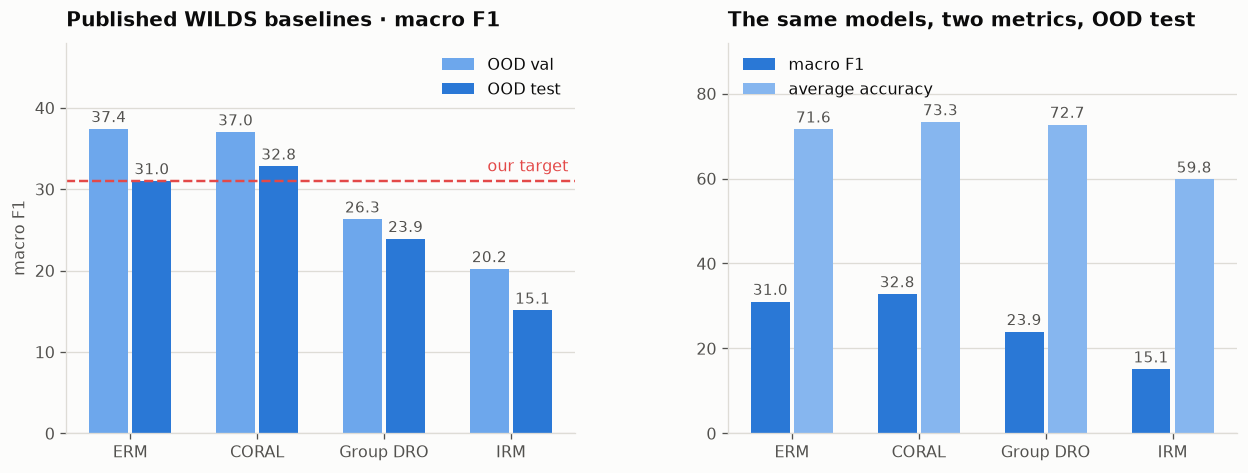

           OOD val macro F1  OOD test macro F1  OOD val avg acc  OOD test avg acc
ERM                    37.4               31.0             62.7              71.6
CORAL                  37.0               32.8             60.3              73.3
Group DRO              26.3               23.9             60.0              72.7
IRM                    20.2               15.1             47.2              59.8

our target: match or beat ERM's 31.0 macro F1 on the OOD test split
best published macro F1 (CORAL): 32.8


**Finding.** The benchmark settles Success Criterion 2. The official metric is **macro F1 on the OOD test split**, which is per-species F1 averaged over classes — **the same thing Success Criterion 1 asks for**, so the two criteria collapse into one measurable number instead of competing. Published baselines give the target: **ERM reaches 31.0 macro F1**, CORAL is best at 32.8, and IRM trails at 15.1. **Success Criterion 2 becomes "match or beat ERM's 31.0 macro F1 on the OOD test split"** — citable, reproducible, and honest about difficulty. The right-hand panel is the warning: the same models score 72–73 average accuracy on those identical predictions. **Reporting accuracy as the headline would overstate the system's real performance by more than a factor of two**, and S4.4 explains why — the accuracy is carried by a few common classes while most of the label space goes unmeasured. Two caveats to carry into the deck: these baselines use the full official label set, so our number is only comparable if we pin the same one (S4.4); and a KARR deployment is a *further* domain shift beyond the one these baselines measure, so the OOD test score is an upper bound on what transfers.

In [ ]:
baselines = pd.DataFrame({
    'OOD val macro F1':   {'ERM': 37.4, 'CORAL': 37.0, 'Group DRO': 26.3, 'IRM': 20.2},
    'OOD test macro F1':  {'ERM': 31.0, 'CORAL': 32.8, 'Group DRO': 23.9, 'IRM': 15.1},
    'OOD val avg acc':    {'ERM': 62.7, 'CORAL': 60.3, 'Group DRO': 60.0, 'IRM': 47.2},
    'OOD test avg acc':   {'ERM': 71.6, 'CORAL': 73.3, 'Group DRO': 72.7, 'IRM': 59.8},
})

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.3))
x = np.arange(len(baselines)); w = .34
b1 = ax.bar(x - w/2, baselines['OOD val macro F1'], w*.9, color=SEQ[4], label='OOD val')
b2 = ax.bar(x + w/2, baselines['OOD test macro F1'], w*.9, color=BLUE, label='OOD test')
ax.bar_label(b1, fmt='%.1f', fontsize=9, color=INK2, padding=2)
ax.bar_label(b2, fmt='%.1f', fontsize=9, color=INK2, padding=2)
ax.set_xticks(x, baselines.index); ax.set_ylabel('macro F1')
ax.set_ylim(0, 48); ax.grid(axis='x', visible=False); ax.legend(loc='upper right')
ax.axhline(baselines.loc['ERM', 'OOD test macro F1'], color=RED, ls='--', lw=1.5)
ax.text(3.45, baselines.loc['ERM', 'OOD test macro F1'] + 1.2, 'our target',
        ha='right', fontsize=9.5, color=RED)
ax.set_title('Published WILDS baselines · macro F1')

b3 = ax2.bar(x - w/2, baselines['OOD test macro F1'], w*.9, color=BLUE, label='macro F1')
b4 = ax2.bar(x + w/2, baselines['OOD test avg acc'], w*.9, color=SEQ[3], label='average accuracy')
ax2.bar_label(b3, fmt='%.1f', fontsize=9, color=INK2, padding=2)
ax2.bar_label(b4, fmt='%.1f', fontsize=9, color=INK2, padding=2)
ax2.set_xticks(x, baselines.index); ax2.set_ylim(0, 92)
ax2.grid(axis='x', visible=False); ax2.legend(loc='upper left')
ax2.set_title('The same models, two metrics, OOD test')
finish(fig, 's5_4_benchmark'); plt.show()

print(baselines.to_string())
print(f"\nour target: match or beat ERM's {baselines.loc['ERM','OOD test macro F1']} macro F1 "
      f"on the OOD test split")
print(f"best published macro F1 (CORAL): {baselines['OOD test macro F1'].max()}")

finding(f'''
The benchmark settles Success Criterion 2. The official metric is **macro F1 on the OOD test
split**, which is per-species F1 averaged over classes — **the same thing Success Criterion 1 asks
for**, so the two criteria collapse into one measurable number instead of competing. Published
baselines give the target: **ERM reaches {baselines.loc['ERM','OOD test macro F1']} macro F1**, CORAL
is best at {baselines['OOD test macro F1'].max()}, and IRM trails at
{baselines['OOD test macro F1'].min()}. **Success Criterion 2 becomes "match or beat ERM's
{baselines.loc['ERM','OOD test macro F1']} macro F1 on the OOD test split"** — citable, reproducible,
and honest about difficulty. The right-hand panel is the warning: the same models score
{baselines.loc['ERM','OOD test avg acc']:.0f}–{baselines['OOD test avg acc'].max():.0f} average
accuracy on those identical predictions. **Reporting accuracy as the headline would overstate the
system's real performance by more than a factor of two**, and S4.4 explains why — the accuracy is
carried by a few common classes while most of the label space goes unmeasured. Two caveats to carry
into the deck: these baselines use the full official label set, so our number is only comparable if
we pin the same one (S4.4); and a KARR deployment is a *further* domain shift beyond the one these
baselines measure, so the OOD test score is an upper bound on what transfers.
''')

---
# Summary

**What the system must handle.** Over a million images a year at KARR scale. About a third are
blank and the cameras fire in bursts, so the real workload is bursts, not frames.

**What it must detect.** 181 species, but one class holds 8% of the dataset and 54 species have ten
photographs or fewer. No bounding boxes ship, and the median animal occupies roughly 1.6% of the
frame.

**Where it operates.** 323 cameras with very uneven effort, no coordinates, and a median of 194
images each.

**What makes it hard.** The official split holds out entire cameras; only 102 of 182 classes survive
into the OOD test set; the label prior shifts more than any appearance axis; half the imagery is
infrared; and a burned-in banner names the camera in the pixels.

**What it delivers.** The table below; every figure is computed in the section named.

### Deck corrections required

| Slide | Says | Should say |
|---|---|---|
| Deliverables | spatial hotspot map | **undeliverable — no coordinates**; ranked station table instead (S3.4) |
| ROI | edge filtering cuts data "up to 60%" | blank filtering alone saves ~33%; **blanks + burst de-duplication** save ~88% (S5.2) |
| Success Criterion 2 | benchmark against a platform classifier | **match or beat ERM's 31.0 macro F1 on WILDS OOD test** (S5.4) |
| Modelling | CNN classifier on full frames | median animal is ~1.6% of frame — **detect-then-crop, or high input resolution** (S2.5) |
| Preprocessing | *(not mentioned)* | **crop top and bottom 5%** to remove the burned-in camera banner (S4.6) |
| Metric | accuracy | **macro F1**; accuracy overstates by >2× on this data (S4.2, S5.4) |

### Limitations

**iWildCam is not KARR.** It is forest and savanna across several continents; KARR is Saudi desert.
Every KARR figure here crosses two extrapolations at once — camera count and biome — and the biome
jump is the riskier one. Desert cameras face heat shimmer and sparse cover, which drive false
triggers up, so the 34% blank rate is the number least likely to transfer and the one carrying most
of the ROI. Effort is approximated by active days because the release ships no deployment windows,
which overstates detection rates at intermittently-quiet cameras (S3.1). Seconds-per-decision and
the filter operating point are assumptions, shown across a range rather than fixed. Image-level
figures come from a location-stratified sample rather than all 203,029 frames, and the animal-size
estimate is an upper bound derived from background subtraction rather than from labelled boxes.

In [ ]:
try:
    FOOTPRINT = f"{fg.fg_frac.median():.1%} of frame (no boxes ship)"
except NameError:
    FOOTPRINT = "unknown - no bounding boxes ship"

summary = pd.DataFrame([
    ('Workload',   'images per year at KARR scale',  f"{karr_year/1e6:.2f}M",            'S1.1'),
    ('Workload',   'blank frames',                   f"{df.is_blank.mean():.1%}",        'S1.2'),
    ('Workload',   'frames per burst',               f"{seq_frames:.2f}",                'S1.2'),
    ('Delivery',   'reviewer-hours per year, now',   f"{base_h:,.0f} h",                 'S1.3'),
    ('Delivery',   'reviewer-hours after the system', f"{filt_h:,.0f} h "
                                                     f"({1-filt_h/base_h:.0%} saved)",   'S5.1'),
    ('Delivery',   'bandwidth saved at the edge',    f"{1-both_keep:.0%}",               'S5.2'),
    ('Delivery',   'rare-species alerts per day',    f"{one_pct.karr_per_day:.1f}",      'S5.3'),
    ('Targets',    'species',                        f"{len(sp_named)}",                 'S2.1'),
    ('Targets',    'proposed class list',            f"{int(keep_mask.sum())} + empty + other", 'S2.2'),
    ('Targets',    'median animal footprint',        FOOTPRINT,                          'S2.5'),
    ('Stations',   'cameras',                        f"{df.location.nunique()}",         'S3.1'),
    ('Stations',   'cameras under 100 images',       f"{thin_cams}",                     'S3.1'),
    ('Stations',   'coordinates available',          'NO',                               'S3.4'),
    ('Constraints', 'classes in train AND OOD test', f"{int((in_train & in_test).sum())} of {int(df.y.nunique())}", 'S4.4'),
    ('Constraints', 'infrared share',                f"{IR_SHARE:.0%}",                  'S4.3'),
    ('Constraints', 'frames with a burned-in banner', f"{dark_bot:.0%}",                 'S4.6'),
    ('Benchmark',  'target macro F1 (OOD test)',     f"{baselines.loc['ERM','OOD test macro F1']}", 'S5.4'),
], columns=['section', 'quantity', 'value', 'where'])
hdr = '| ' + ' | '.join(summary.columns) + ' |'
sep = '|' + '|'.join(['---'] * len(summary.columns)) + '|'
rows = ['| ' + ' | '.join(str(v) for v in r) + ' |' for r in summary.values]
display(Markdown(chr(10).join([hdr, sep] + rows)))

| section | quantity | value | where |
|---|---|---|---|
| Workload | images per year at KARR scale | 1.01M | S1.1 |
| Workload | blank frames | 34.2% | S1.2 |
| Workload | frames per burst | 5.56 | S1.2 |
| Delivery | reviewer-hours per year, now | 844 h | S1.3 |
| Delivery | reviewer-hours after the system | 88 h (90% saved) | S5.1 |
| Delivery | bandwidth saved at the edge | 88% | S5.2 |
| Delivery | rare-species alerts per day | 60.7 | S5.3 |
| Targets | species | 181 | S2.1 |
| Targets | proposed class list | 65 + empty + other | S2.2 |
| Targets | median animal footprint | 1.6% of frame (no boxes ship) | S2.5 |
| Stations | cameras | 323 | S3.1 |
| Stations | cameras under 100 images | 104 | S3.1 |
| Stations | coordinates available | NO | S3.4 |
| Constraints | classes in train AND OOD test | 102 of 182 | S4.4 |
| Constraints | infrared share | 46% | S4.3 |
| Constraints | frames with a burned-in banner | 45% | S4.6 |
| Benchmark | target macro F1 (OOD test) | 31.0 | S5.4 |